In [1]:
import pandas as pd
import numpy as np
from pygam import LinearGAM, s, te, intercept 
import matplotlib.pyplot as plt
import geopandas as gpd
from matplotlib.path import Path
from shapely.geometry import Polygon, MultiPolygon
from scipy.stats import norm, t as student_t
from matplotlib import colors
import torch.nn.functional as Fnn

import math
import torch
import torch.nn as nn
import torch.optim as optim
import gpytorch
from torch.distributions import Normal
from dataclasses import dataclass
from kmeans_pytorch import kmeans

torch.set_default_dtype(torch.float64)

# 1. t base model g replace normal base model g tilde, use student_t(df, loc=mu, scale=sigma), which automatically does moment matching. df=3 and check z plot.
# 2. Update all the visualisation by comparing predicted h, g and g tilde.
# 3. Optimizor use Adam and larger number of steps
# 4. Hyperparameter selection via cross validation



Base model fitting

In [2]:
#set random seed for reproducibility
torch.manual_seed(1)
np.random.seed(1)

In [3]:
# data preparation
df = pd.read_csv("weather_data.csv",index_col="date")
df.index = pd.to_datetime(df.index)

df['t'] = (df.index-df.index[0])/pd.Timedelta(days=1)
df["t"] = df["t"]/df["t"].max() # time 0-1


# # only use data in time (1/6, 1/3) - approximately one year
df = df[(df['t']>1/6) & (df['t']<2/6)].copy()
df["t"] = (df["t"]-df["t"].min())/(df["t"].max()-df["t"].min()) # time 0-1


# ################

# # Gentle quantile-based outlier filtering by temperature
# temp = df['temperature'].values
# ql = np.quantile(temp, 0.01)
# qh = np.quantile(temp, 0.99)
# mask_inliers = (temp >= ql) & (temp <= qh)
# removed_temps = df.loc[~mask_inliers, 'temperature'].values
# df_filtered = df.loc[mask_inliers].copy()

# # Report removal summary
# print(f"Quantile filter: keep within [1%, 99%] range")
# print(f"Removed {removed_temps.shape[0]} / {mask_inliers.shape[0]} observations ({(removed_temps.shape[0]/mask_inliers.shape[0])*100:.2f}%).")
# print(f"Original temperature range: [{df['temperature'].min():.2f}, {df['temperature'].max():.2f}] °C ")
# print(f"Kept temperature range: [{df_filtered['temperature'].min():.2f}, {df_filtered['temperature'].max():.2f}] °C")

# df = df_filtered

# ################

X = df[['t','longitude','latitude']].values
y = df['temperature'].values


# # # map X to [-1, 1] and standardize y to have mean 0 and std 1 for better numerical stability

# standardize X 
x_mean = X.mean(axis=0)
x_std = X.std(axis=0)
X = (X - x_mean) / x_std

# map X to [-1, 1]
X = (2 / (1+np.exp(-X))) - 1

# standardize y
y_mean = y.mean()
y_std = y.std()
y = (y - y_mean) / y_std



In [4]:
x_all, y_all = X, y
rand_indices = torch.randperm(x_all.shape[0], generator=torch.Generator())
x_train, y_train = x_all[rand_indices[:-x_all.shape[0]//10]], y_all[rand_indices[:-x_all.shape[0]//10]]  # 90% train, 10% test
x_test, y_test = x_all[rand_indices[-x_all.shape[0]//10:]], y_all[rand_indices[-x_all.shape[0]//10:]]

(array([2445., 5091., 5110., 4380., 3285., 4015., 4015., 4959., 2920.,
        2906., 4380., 2555., 4380., 1825., 4745., 2555., 3650., 3285.,
        1427., 4380., 3285., 4719., 4380., 3285., 5110., 5110., 4380.,
        2920., 3650., 3285., 2920., 3428., 4003., 2190., 3285., 1460.,
        2920., 3650., 1825.,  611., 3137., 2555., 1825., 2920., 4015.,
        2918., 4551., 3832., 2555.,  730.]),
 array([-0.70779728, -0.6774932 , -0.64718912, -0.61688504, -0.58658095,
        -0.55627687, -0.52597279, -0.49566871, -0.46536463, -0.43506055,
        -0.40475647, -0.37445239, -0.34414831, -0.31384423, -0.28354015,
        -0.25323607, -0.22293198, -0.1926279 , -0.16232382, -0.13201974,
        -0.10171566, -0.07141158, -0.0411075 , -0.01080342,  0.01950066,
         0.04980474,  0.08010882,  0.1104129 ,  0.14071699,  0.17102107,
         0.20132515,  0.23162923,  0.26193331,  0.29223739,  0.32254147,
         0.35284555,  0.38314963,  0.41345371,  0.44375779,  0.47406187,
         0.50436

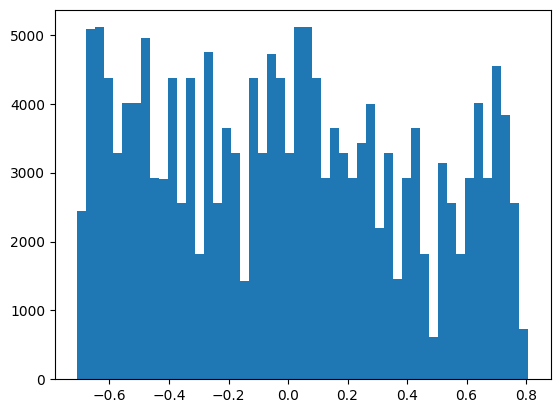

In [5]:
plt.hist(x_all[:,2], bins=50)

In [6]:
# fit the GAM model
gam = LinearGAM(intercept + s(0,n_splines=5)+te(1,2,n_splines=[5,5]))
# gam = LinearGAM(intercept + s(0,n_splines=10)+te(1,2,n_splines=[5,5]))
# LinearGAM(intercept + s(0,n_splines=10)+te(1,2,n_splines=[10,10]÷))
# LinearGAM(intercept + s(0,n_splines=10)+s(1,n_splines=10)+s(2,n_splines=10))

gam.fit(x_train,y_train)

print(gam.summary())

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                     19.0087
Link Function:                     IdentityLink Log Likelihood:                               -214078.3519
Number of Samples:                       150985 AIC:                                           428196.7212
                                                AICc:                                          428196.7268
                                                GCV:                                                 0.285
                                                Scale:                                               0.285
                                                Pseudo R-Squared:                                   0.7155
Feature Function                  Lam

/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_33586/3768786032.py:9: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [7]:
# parameters of the base model for each observation
df["mu"] = gam.predict(X) 
df["sigma"] = np.std(y-df["mu"])#gam.statistics_["scale"] # a single scale estimate for all data points
df["z"] = norm(loc=df["mu"],scale=df["sigma"]).cdf(y) # base model cdf value z = G(y|x)

# df.to_csv("weather_data_basefit.csv")

# Base model constants: g_tilde (Normal GAM) and g (moment-matched t-distribution)
# g_tilde: Normal base model from GAM (used for visualization later)
SIGMA_NORMAL = np.std(y-df["mu"])#gam.statistics_["scale"] # Same scale as GAM

ORIGINAL_SIGMA_NORMAL = SIGMA_NORMAL  # Store the original GAM-based scale for reference

SIGMA_NORMAL = SIGMA_NORMAL * 3.0  # Adjust this factor to control how closely g_tilde matches the GAM fit (1.0 means exact match)


# g: t-distributed base model with moment matching (used in GPDR optimization)
# Uses the same location (GAM prediction) and scale as g_tilde, but with heavier tails (df=3)
SCALE_T = SIGMA_NORMAL  # Moment-matched scale
DF = 3.0  # Degrees of freedom for t-distribution

print(f"Base model g_tilde (Normal GAM): scale = {SIGMA_NORMAL:.4f}")
print(f"Base model g (t-dist): scale = {SCALE_T:.4f}, df = {DF}")

Base model g_tilde (Normal GAM): scale = 1.5995
Base model g (t-dist): scale = 1.5995, df = 3.0


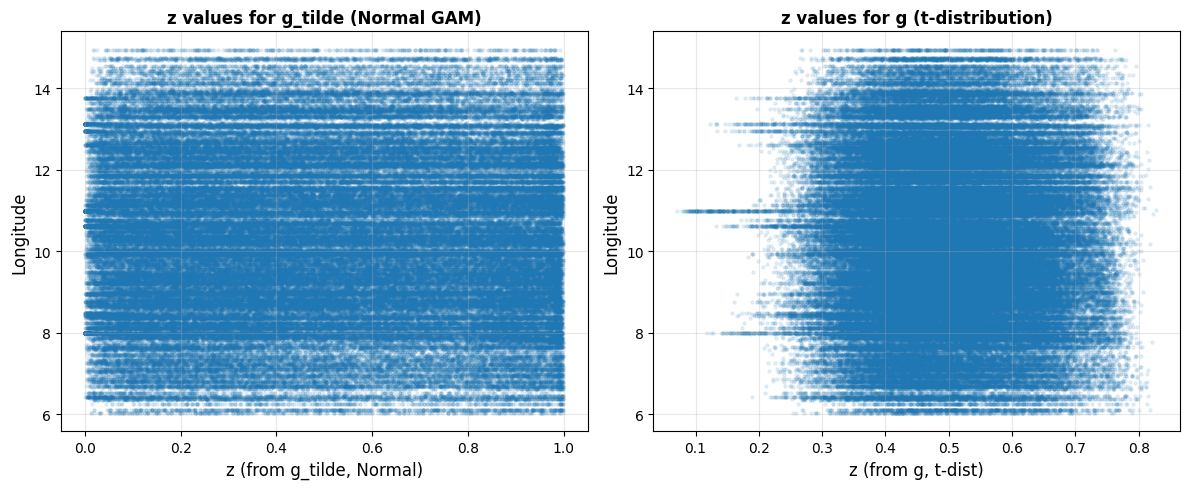

In [8]:
# Compute z values for both base models
# z for g_tilde (Normal): already computed as df["z"]
# z for g (t-distribution): compute using t-distribution CDF
df["z_t"] = student_t.cdf(y, DF, loc=df["mu"], scale=SCALE_T)

# Create side-by-side comparison plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot for g_tilde (Normal base)
ax1.scatter(df.z, df.longitude, alpha=0.1, s=5)
ax1.set_xlabel('z (from g_tilde, Normal)', fontsize=12)
ax1.set_ylabel('Longitude', fontsize=12)
ax1.set_title('z values for g_tilde (Normal GAM)', fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot for g (t-distribution base)
ax2.scatter(df.z_t, df.longitude, alpha=0.1, s=5)
ax2.set_xlabel('z (from g, t-dist)', fontsize=12)
ax2.set_ylabel('Longitude', fontsize=12)
ax2.set_title('z values for g (t-distribution)', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


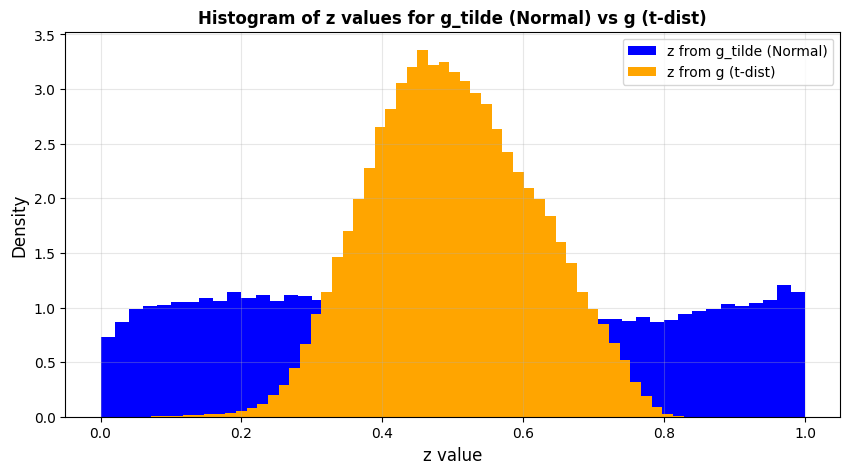

In [9]:
# z values histogram
plt.figure(figsize=(10, 5))
plt.hist(df.z, bins=50, alpha=1, label='z from g_tilde (Normal)', color='blue', density=True)
plt.hist(df.z_t, bins=50, alpha=1, label='z from g (t-dist)', color='orange', density=True)
plt.xlabel('z value', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Histogram of z values for g_tilde (Normal) vs g (t-dist)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
print(gam.distribution._known_scale) # In this base model, we do not announce a scale for response varianble distirbution
# Therefore, by classical GAM theory, the scale parameter is estimated

print(gam.statistics_["scale"])

False
0.28498460079055776


In [11]:
import os
os.environ["SHAPE_RESTORE_SHX"] = "YES" # to make de.shp file work in geopandas


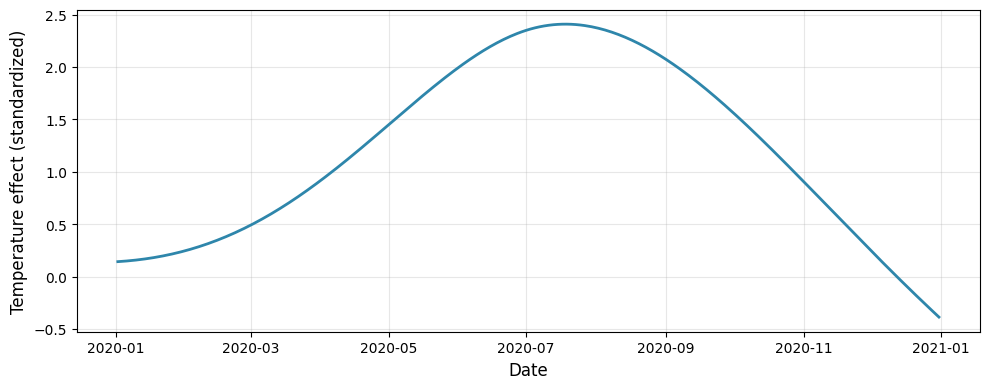

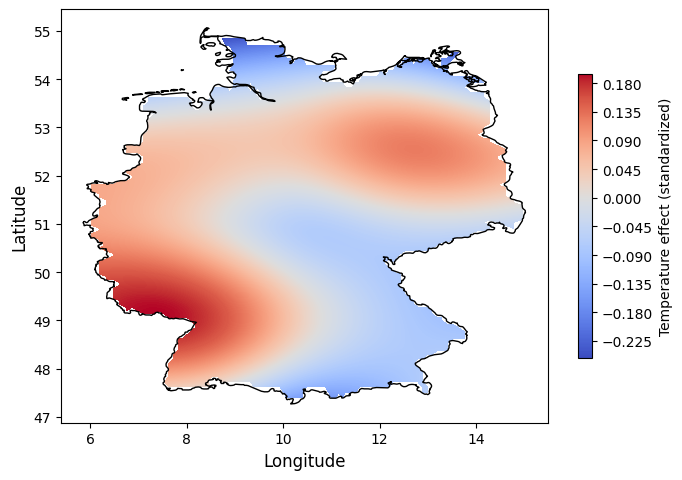

In [12]:
############################
### plots of the effects ###
############################

def points_in_polygon_path(xy, poly: Polygon):
    # exterior
    ext_path = Path(np.asarray(poly.exterior.coords))
    inside_ext = ext_path.contains_points(xy)
    # holes (interiors)
    if len(poly.interiors):
        inside_holes = np.zeros(xy.shape[0], dtype=bool)
        for ring in poly.interiors:
            hole_path = Path(np.asarray(ring.coords))
            inside_holes |= hole_path.contains_points(xy)
        return inside_ext & ~inside_holes
    else:
        return inside_ext

# Seasonal effect (temporal effect)
f_t = gam.partial_dependence(term=1, X=X)   # how the model's prediction changes when a date changes, while averaging over all other features, i.e. Seasonal effect
plt.figure(figsize=(10, 4))
plt.plot(df.index, f_t, color='#2E86AB', linewidth=2)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature effect (standardized)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('base_model_temporal_effect.pdf', dpi=300, bbox_inches='tight')
plt.show()

XX = gam.generate_X_grid(term=2, meshgrid=True)
Z = gam.partial_dependence(term=2, X=XX, meshgrid=True) # te(lon,lat) effect

Z = Z-Z.mean()


# # Convert XX back to original longitude/latitude scale for visualization
# XX_original = [
#     XX[0] * x_std[1] + x_mean[1],  # longitude (index 1 in X)
#     XX[1] * x_std[2] + x_mean[2]   # latitude (index 2 in X)
# ]

# if inlucde map, apply inverse of map X = (2 / (1+np.exp(-X))) - 1
XX_original = [
    -np.log(2/(XX[0]+1)-1) * x_std[1] + x_mean[1],  # longitude (index 1 in X)
    -np.log(2/(XX[1]+1)-1) * x_std[2] + x_mean[2]   # latitude (index 2 in X)
]



gdf = gpd.read_file("de.shp")
gdf = gdf.explode(index_parts=False)

x_flat = XX_original[0].ravel()
y_flat = XX_original[1].ravel()
xy = np.column_stack([x_flat, y_flat]) # locations of each grid points

outside = np.ones(xy.shape[0], dtype=bool)

for geom in gdf.geometry:
    if isinstance(geom, Polygon):
        inside_poly = points_in_polygon_path(xy, geom)
        outside &= ~inside_poly  
    elif isinstance(geom, MultiPolygon):
        inside_any = np.zeros(xy.shape[0], dtype=bool)
        for part in geom.geoms:
            inside_any |= points_in_polygon_path(xy, part)
        outside &= ~inside_any
    else:
        continue

mask = outside.reshape(XX_original[0].shape)
Z_masked = np.ma.array(Z, mask=mask)

fig, ax = plt.subplots(figsize=(7, 6))
vmin = np.nanmin(Z_masked)
vmax = np.nanmax(Z_masked)
norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=0.0, vmax=vmax)
cm = ax.contourf(XX_original[0], XX_original[1], Z_masked, levels=300, cmap='coolwarm',norm=norm)
gdf.boundary.plot(ax=ax, color='k', linewidth=1.0)
fig.colorbar(cm, ax=ax, shrink=0.5, label='Temperature effect (standardized)')
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('base_model_spatial_effect.pdf', dpi=300, bbox_inches='tight')
plt.show()


GP density approximation

In [ ]:
# Minimal PyTorch + GPyTorch implementation of Logistic GP density regression
# with a mixture variational posterior over f_z at inducing points
# (learns mixture weights ω, means μ_k, and diagonal covariances Σ_k = diag(v_k)).

# All the x, y's are torch tensors

dim_x = 3

def normal_pdf(y, mu, sigma):
    # torch-normal PDF (kept for reference)
    return (1.0 / (math.sqrt(2.0 * math.pi) * sigma)) * torch.exp(-0.5 * ((y - mu) / sigma)**2)

def t_pdf(y, mu, sigma, df=DF):
    """
    Student's t-distribution PDF using scipy.
    Returns PDF of t(loc=mu, scale=sigma, df=df) at y.
    """
    # Convert to numpy for scipy
    mu_np = mu.cpu().numpy() if torch.is_tensor(mu) else mu
    sigma_np = sigma if isinstance(sigma, float) else sigma.cpu().numpy() if torch.is_tensor(sigma) else sigma
    y_np = y.cpu().numpy()
    
    # Use scipy student_t
    pdf_np = student_t.pdf(y_np, df, loc=mu_np, scale=sigma_np)
    return torch.tensor(pdf_np, dtype=y.dtype, device=y.device)

def base_g_terms(y, x, sigma=SCALE_T, df=DF):
    """
    Base model using Student's t-distribution: t(loc=GAM(x), scale=sigma, df=df).
    Returns g(y|x), g'(y|x), g''(y|x).
    Uses scipy.stats.student_t.
    """
    # Convert to numpy for GAM prediction, then back to tensor
    mu = torch.tensor(gam.predict(x.cpu().numpy()), device=x.device, dtype=x.dtype)
    
    # Convert to numpy for scipy
    mu_np = mu.cpu().numpy()
    sigma_np = sigma if isinstance(sigma, float) else sigma
    y_np = y.cpu().numpy()
    
    # Use scipy.stats.student_t for PDF
    g_np = student_t.pdf(y_np, df, loc=mu_np, scale=sigma_np)
    g = torch.tensor(g_np, dtype=y.dtype, device=y.device)
    
    # Compute derivatives using manual formulas
    z = (y - mu) / sigma
    gy = -(df + 1) * z * g / (sigma * (df + z**2))
    gyy = g * (-(df + 1) / (sigma**2 * (df + z**2)) + (df + 1) * z**2 * (df + 3) / (sigma**2 * (df + z**2)**2))
    
    return g, gy, gyy

def to_z_from_y(y, x, sigma=SCALE_T, df=DF):
    """
    Transform y to z using CDF of Student's t-distribution.
    z = CDF_t((y - mu) / sigma)
    Uses t(loc=GAM(x), scale=sigma, df=df).
    """
    # Convert to numpy for GAM prediction
    mu = torch.tensor(gam.predict(x.cpu().numpy()), device=x.device, dtype=x.dtype)
    
    # Use scipy.stats.t with explicit loc and scale
    mu_np = mu.cpu().numpy()
    sigma_np = sigma if isinstance(sigma, float) else sigma
    y_np = y.cpu().numpy()
    z_np = student_t.cdf(y_np, df, loc=mu_np, scale=sigma_np)
    z = torch.tensor(z_np, dtype=y.dtype, device=y.device)
    
    return z

# -----------------------------
# 2) Kernel (RBF with ARD) and derivative blocks
# -----------------------------

@dataclass #0.9 0.22 0.22
class KernelParams:
    log_sigma2: float = math.log(0.4240**2)
    log_lz2: float    = math.log(0.5469**2)
    
    def get_lx2(self, device, dtype):
        """Get lengthscale tensor on the correct device/dtype"""
        log_lx2 = torch.tensor([math.log(0.3290**2) for s in range(dim_x)], device=device, dtype=dtype)
        return torch.exp(log_lx2)

    @property
    def sigma2(self): return math.exp(self.log_sigma2)
    @property
    def lz2(self):    return math.exp(self.log_lz2)

class RBF_SE_ARD(nn.Module):
    """
    Just wraps GPyTorch's RBFKernel+ScaleKernel to compute the base k((x,z),(x',z')).
    We still implement the derivative covariances in closed-form (simple and fast).
    """
    def __init__(self, kp: KernelParams, device=torch.device("cpu"), dtype=torch.float32):
        super().__init__()
        self.register_buffer("lx2", kp.get_lx2(device, dtype)) # lx2 = 1/lengthscale_x^2
        self.register_buffer("lz2", torch.tensor(kp.lz2, device=device, dtype=dtype)) # lz2 = 1/lengthscale_z
        self.register_buffer("sigma2", torch.tensor(kp.sigma2, device=device, dtype=dtype))
        # A small GPyTorch kernel to show usage (we won't use autograd for derivatives here).
        self.base = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(ard_num_dims=1+dim_x, has_lengthscale=True)
        )
        # Fix the hyperparameters for presentation clarity:
        with torch.no_grad():
            # lengthscales per-dimension: [sqrt(lx2), sqrt(lz2)]
            lx2_cpu = kp.get_lx2(torch.device("cpu"), torch.float64)  # GPyTorch needs CPU tensors
            lz2_cpu = torch.tensor(kp.lz2, dtype=torch.float64)
            self.base.base_kernel.lengthscale = torch.sqrt(torch.cat([lx2_cpu.reshape(1,-1), lz2_cpu.reshape(1,-1)],dim=1)[None, None, :])
            self.base.outputscale = torch.tensor(kp.sigma2, dtype=torch.float64) # initialized value of σ^2 for covariance function



    def delta_01(self, V, U):
        # Cov(f, f'_z) = ∂/∂z' k
        # Using closed-form for RBF:
        # k = σ^2 exp(-(dx^2/lx2 + dz^2/lz2))
        # ∂k/∂z' = k * (2 (z - z') / lz2)
        x1 = V[:, 0:-1]; z1 = V[:, -1:]
        x2 = U[:, 0:-1].T; z2 = U[:, -1:].T
        x1 = V[:, 0:-1][:, None, :]   # shape (n,1,dim_x)
        x2 = U[:, 0:-1][None, :, :]   # shape (1,n,dim_x)
        dist2 = (x1 - x2)**2 / self.lx2  # shape (n,n,dim_x)
        dx2 = dist2.sum(-1)  # shape (n,n)

        dz  = (z1 - z2)
        dz2 = (dz**2) / self.lz2
        K = self.sigma2 * torch.exp(-(dx2 + dz2))
        return K * (2.0 * dz / self.lz2)


    def delta_11(self, V, U):
        # Cov(f'_z, f'_z) = ∂^2/(∂z ∂z') k
        x1 = V[:, 0:-1]; z1 = V[:, -1:]
        x2 = U[:, 0:-1].T; z2 = U[:, -1:].T
        x1 = V[:, 0:-1][:, None, :]   # shape (n,1,dim_x)
        x2 = U[:, 0:-1][None, :, :]   # shape (1,n,dim_x)
        dist2 = (x1 - x2)**2 / self.lx2  # shape (n,n,dim_x)
        dx2 = dist2.sum(-1)  # shape (n,n)

        # print(dx2.shape) # should be (n,m)/(m,m) --- DEBUG ---
        dz  = (z1 - z2)
        dz2 = (dz**2) / self.lz2
        K = self.sigma2 * torch.exp(-(dx2 + dz2))
        result = (2.0/self.lz2) * K * (1.0 - 2.0 * (dz2))

        # Add small nugget to diagonal for numerical stability
        if V.shape[0] == U.shape[0] and torch.allclose(V, U):
            result += 1e-10 * torch.eye(V.shape[0], dtype=V.dtype, device=V.device)
            
        return result

    def delta_21(self, V, U):
        # Cov(f''_z, f'_z) = ∂^3/(∂z^2 ∂z') k
        x1 = V[:, 0:-1]; z1 = V[:, -1:]
        x2 = U[:, 0:-1].T; z2 = U[:, -1:].T

        x1 = V[:, 0:-1][:, None, :]   # shape (n,1,2)
        x2 = U[:, 0:-1][None, :, :]   # shape (1,n,2)
        dist2 = (x1 - x2)**2 / self.lx2  # shape (n,n,2)
        dx2 = dist2.sum(-1)  # shape (n,n)

        dz  = (z1 - z2)
        dz2 = (dz**2) / self.lz2
        K = self.sigma2 * torch.exp(-(dx2 + dz2))
        return K * (8.0 * (dz**3) / (self.lz2**3) - 12.0 * dz / (self.lz2**2))
    

def chol_inv(K):
    """Improved Cholesky inversion with MPS compatibility"""
    try:
        L = torch.linalg.cholesky(K)
        I = torch.eye(K.size(-1), dtype=K.dtype, device=K.device)
        
        # MPS doesn't support cholesky_solve, use alternative approach
        if K.device.type == "mps":
            # Solve L @ L.T @ X = I using forward and backward substitution
            # First solve L @ Y = I for Y
            Y = torch.linalg.solve_triangular(L, I, upper=False)
            # Then solve L.T @ X = Y for X
            Kinv = torch.linalg.solve_triangular(L.T, Y, upper=True)
        else:
            # Use cholesky_solve for CUDA/CPU
            Kinv = torch.cholesky_solve(I, L)
        return Kinv, L
    except Exception as e:
        # Fallback to SVD-based pseudoinverse if Cholesky fails
        print(f"Cholesky failed: {e}, using SVD fallback")
        U, S, Vt = torch.linalg.svd(K)
        # Filter out small singular values
        threshold = 1e-10 * S[0]  # relative to largest singular value
        S_inv = torch.where(S > threshold, 1.0 / S, 0.0)
        Kinv = (Vt.T * S_inv.unsqueeze(0)) @ Vt
        return Kinv, None


# -----------------------------
# 3) Variational mixture over f_z (diagonal Σ_k)
# -----------------------------
class LogisticGPMixtureDiag(nn.Module):
    """
    Variational family: q(f̃_z) = Σ_k ω_k N(μ_k, diag(v_k)), v_k = exp(2 s_k).
    Minimizes:  KL(q || GP prior on f'_z at inducing) + β * Hyvärinen score.
    """
    def __init__(self, x, y, C=2, m_induce=121, beta=1.0, kp: KernelParams = KernelParams()):
        super().__init__()
        g = torch.Generator()

        self.x = x.detach()
        self.y = y.detach()
        self.n = x.numel()
        self.C = C
        self.beta = beta
        self.kern = RBF_SE_ARD(kp, device=self.x.device, dtype=self.x.dtype)

        # Transform to z and build training inputs V = (x, z)
        z = to_z_from_y(self.y, self.x)
        z = torch.clamp(z, 1e-5, 1-1e-5)

        self.V = torch.cat([self.x, z.reshape(-1,1)], dim=1)  # (n, dim_x + 1)


        # Proper (dim_x+1)-D grid inducing points for better coverage (degenerated)
        # Create a (dim_x+1)-D grid instead of random points to ensure good coverage
        # n_per_dim = int(round(m_induce ** (1/(dim_x+1))))  # root for (dim_x+1)-D grid
        # grid_list = []
        # for u in range(dim_x+1):
        #     if u != dim_x:
        #         x_grid = torch.linspace(self.x[:,u].min()+1e-5, self.x[:,u].max()-1e-5, n_per_dim, device=self.x.device, dtype=self.x.dtype)
        #         grid_list.append(x_grid)
        #     else:
        #         z_grid = torch.linspace(1e-5, 1-1e-5, n_per_dim, device=self.x.device, dtype=self.x.dtype)
        #         grid_list.append(z_grid)

        # # Create 3D meshgrid and flatten to get inducing points
        # grid_mesh = torch.meshgrid(*grid_list, indexing='ij')
        # self.Vu = torch.stack(grid_mesh, dim=-1).reshape(-1, len(grid_list))  # (m, dim_x + 1)

        # # standardize self.x for clustering using min-max scaling
        # x_min = self.x.min(dim=0).values
        # x_max = self.x.max(dim=0).values
        # x_standardized = (self.x - x_min) / (x_max - x_min)


        # Using Kmeans clustering
        n_per_dim = int(round(m_induce ** (1/(dim_x+1))))  # root for (dim_x+1)-D grid
        totalnum_xpoints = n_per_dim ** dim_x
        
        # Perform final clustering with optimal k
        optimal_k = totalnum_xpoints  # from previous determination
        cluster_ids_x, cluster_centers = kmeans(
            X=self.x, num_clusters=optimal_k, distance='euclidean', device=self.x.device
        )
        # Determine number of clusters end
        
        points_allcluster = torch.zeros((0, dim_x), device=self.x.device, dtype=self.x.dtype)
        for u in range(optimal_k):
            cluster_center = torch.tensor(cluster_centers[u], device=self.x.device, dtype=self.x.dtype) # cluster_centers[u].detach().clone().requires_grad_(True) # 
            points_allcluster = torch.cat([points_allcluster, cluster_center.unsqueeze(0)], dim=0)
        
        x_grid = points_allcluster[1:,:] # remove the initial zero row, now size is (optimal_k, dim_x)
        z_grid = torch.linspace(1e-5, 1-1e-5, n_per_dim, device=self.x.device, dtype=self.x.dtype)


        # Create 3D meshgrid and flatten to get inducing points

        x_grid_expand = x_grid[:, None, :].expand(x_grid.size(0), n_per_dim, dim_x)   # (m,n,d)
        z_grid_expand = z_grid[None, :, None] .expand(x_grid.size(0), n_per_dim, 1)   # (m,n,1)

        out = torch.cat([x_grid_expand, z_grid_expand], dim=2).reshape(x_grid.size(0)*n_per_dim, dim_x+1)
        # print(out.shape) # should be (m, dim_x+1)

        self.Vu = out  # (x_grid.size(0), dim_x + 1)

        self.m = self.Vu.size(0)

        # Base model terms
        self.g, self.gy, self.gyy = base_g_terms(self.y, self.x)

        # Kernel blocks
        self.K11uu = self.kern.delta_11(self.Vu, self.Vu)        # (m, m)
        self.K11uu_inv, self.K11uu_chol = chol_inv(self.K11uu) 
        self.A = self.kern.delta_11(self.V, self.Vu) @ self.K11uu_inv   # (n, m)
        # self.A = torch.linalg.solve(self.K11uu.T, self.kern.delta_11(self.V, self.Vu).T).T
        self.B = self.kern.delta_21(self.V, self.Vu) @ self.K11uu_inv   # (n, m)
        # self.B = torch.linalg.solve(self.K11uu.T, self.kern.delta_21(self.V, self.Vu).T).T

        self.A2 = self.A**2
        self.A2T_g2_over_n = self.A2.T @ ((self.g**2) / self.n)  # (m,)

        # Variational parameters
        self.logits = nn.Parameter(torch.randn(C, device=self.x.device, dtype=self.x.dtype))                       # mixture weights (softmax)
        self.mus    = nn.Parameter(torch.randn(C, self.m, device=self.x.device, dtype=self.x.dtype))               # means
        init_log_std = math.log(0.35)
        self.s_params = nn.Parameter(torch.full((C, self.m), init_log_std, device=self.x.device, dtype=self.x.dtype))  # log std per inducing point per mixture component

        # Warm-start μ (single-component quadratic surrogate)
        self.warm_start_mu()

    def warm_start_mu(self):
        c = self.gy / self.g
        lin = (2.0 * self.gy + 2.0 * c * self.g)              # (n,)
        W = (self.g ** 2)                                     # (n,)
        AtW = self.A.T * (W / self.n)                         # (m, n)
        H = self.K11uu_inv + 2.0 * self.beta * (AtW @ self.A) # (m, m)
        b = self.beta * (self.A.T @ (lin / self.n))           # (m,)
        
        # # Use Cholesky for warm start - with MPS compatibility
        # try:
        #     L = torch.linalg.cholesky(H)
        #     mu_ls = -torch.cholesky_solve(b.unsqueeze(-1), L).squeeze(-1)
        # except:
        # Fallback to direct solve if Cholesky fails
        mu_ls = -torch.linalg.solve(H, b)
        

        with torch.no_grad():
            for k in range(self.C):
                self.mus[k].copy_(mu_ls / self.C + 0.03 * torch.randn_like(mu_ls))

    def forward_objective(self):
        """
        Compute the scalar objective and autograd will populate grads:
        F = KL(q || GP prior) + β * EH
        """
        # print(self.K11uu_inv)
        logits = self.logits
        w = torch.softmax(logits, dim=0)                           # (C,)

        aMu = (self.A @ self.mus.T).T                              # (C, n)
        mu_bar = torch.sum(w[:, None] * self.mus, dim=0)           # (m,)
        Ez = self.A @ mu_bar                                       # (n,)
        Efzz = self.B @ mu_bar                                     # (n,)

        g, gy, gyy = self.g, self.gy, self.gyy
        c = gy / g
        # const = 2.0 * ((g * gyy - gy**2) / (g**2)) + c**2          # (n,)
        # lin_coeff = 2.0 * gy + 2.0 * c * g                         # (n,)

        const     = (gyy / g) - 0.5 * (c**2)     # constant part
        lin_coeff = 2.0 * gy                      # linear-in-E[f_z]


        # ---- Var(f_z) for each component: diag(A diag(v_k) A^T) ----
        v_list = torch.exp(2.0 * self.s_params)                    # (C, m)
        row_var = (self.A2 @ v_list.T).T                           # (C, n)  each row k: A^2 v_k
        Efz2 = torch.sum(w[:, None] * (row_var + aMu**2), dim=0)   # (n,)
        # EH = torch.mean(const + lin_coeff * Ez + (g**2) * Efz2 + 2.0 * (g**2) * Efzz)
        EH = torch.mean(const + lin_coeff * Ez + 0.5 * (g**2) * Efz2 + 1.0 * (g**2) * Efzz)

        # ---- KL(q || GP prior) ----
        # KL per component vs N(0, K11uu)
        Kinv = self.K11uu_inv
        
        # More stable log determinant computation
        if self.K11uu_chol is not None:
            logdetK = 2.0 * torch.log(torch.diag(self.K11uu_chol)).sum()
        else:
            sign, logdetK = torch.slogdet(self.K11uu)

        # sign, logdetK = torch.slogdet(self.K11uu)
            
        diag_Kinv = torch.diag(Kinv)
        KL_k = []
        for k in range(self.C):
            mu_k = self.mus[k]                      # (m,)
            v_k  = v_list[k]                        # (m,)
            quad = mu_k @ (Kinv @ mu_k)            # scalar # torch.solve(K, mu_k)
            # quad = mu_k @ torch.linalg.solve(self.K11uu, mu_k)
            tr   = torch.dot(diag_Kinv, v_k)       # scalar
            logdetSigma = 2.0 * torch.sum(self.s_params[k])
            KL_k.append(0.5 * (tr + quad - self.m + logdetK - logdetSigma))

        # KL per component vs N(0, K11uu)
        KL_k = torch.stack(KL_k)        # (C,)
        KL = torch.sum(w * KL_k)
        
        normalized_EH = self.beta * self.n * EH
        F = KL + normalized_EH


        # print(KL, EH)
        return F, {"KL": KL.detach(), "normalized EH": normalized_EH.detach(), "w": w.detach()}

    # Prediction: mean-only (uses mixture-mean of μ_k), same normalization as NumPy version
    @torch.no_grad()
    def predict_density(self, x_star: float, y_min, y_max, M=1000):
        y_grid = torch.linspace(y_min, y_max, M, dtype=self.x.dtype, device=self.x.device)
        z_grid = to_z_from_y(y_grid, torch.tensor(x_star, device=self.x.device, dtype=self.x.dtype).repeat(M, 1)) # torch.tensor(x_star).repeat(M, 1)
        z_grid = torch.clamp(z_grid, 1e-6, 1-1e-6)

        Vq = torch.cat([torch.tensor(x_star, device=self.x.device, dtype=self.x.dtype).repeat(z_grid.size(0), 1), z_grid.reshape(-1, 1)], dim=1) # (M, dim_x+1), z is (M,1), x_star must be (2,) list/tuple
        # Use the same kernel matrices as during training for consistency
        K01 = self.kern.delta_01(Vq, self.Vu)
        
        w = torch.softmax(self.logits, dim=0)
        m_tilde = torch.sum(w[:, None] * self.mus, dim=0)           # (m,)
        alpha = self.K11uu_inv @ m_tilde
        f_vals = K01 @ alpha                                       # (M,)
        
        g_vals, _, _ = base_g_terms(y_grid, torch.tensor(x_star, device=self.x.device, dtype=self.x.dtype).repeat(M, 1))
        
        # Also compute g_tilde (Normal GAM base model) for comparison using ORIGINAL_SIGMA_NORMAL (unscaled)
        mu_gam = torch.tensor(gam.predict(torch.tensor(x_star, device=self.x.device, dtype=self.x.dtype).repeat(M, 1).cpu().numpy()), device=self.x.device, dtype=self.x.dtype)
        g_tilde_vals = (1.0 / (math.sqrt(2.0 * math.pi) * ORIGINAL_SIGMA_NORMAL)) * torch.exp(-0.5 * ((y_grid - mu_gam) / ORIGINAL_SIGMA_NORMAL)**2)

        # Improved normalization - more stable trapezoid rule
        idx = torch.argsort(z_grid)
        z_sorted = z_grid[idx]
        f_sorted = f_vals[idx]
        
        # Calculate dz BEFORE using it in trapezoid weights
        dz = z_sorted[1:] - z_sorted[:-1]
        
        # Standard trapezoid weights
        wts = torch.zeros_like(z_sorted)
        wts[0] = dz[0] / 2.0
        wts[-1] = dz[-1] / 2.0
        wts[1:-1] = (dz[:-1] + dz[1:]) / 2.0
        
        # Clamp exponential to avoid overflow
        exp_f = torch.exp(f_sorted) # torch.clamp(f_sorted, -50, 50)
        denom = torch.sum(exp_f * wts) + 1e-12
        h_hat = g_vals * torch.exp(f_vals) / denom # torch.exp(torch.clamp(f_vals, -50, 50))

        return y_grid.cpu().numpy(), g_vals.cpu().numpy(), g_tilde_vals.cpu().numpy(), h_hat.cpu().numpy(), exp_f.cpu().numpy(), z_grid.cpu().numpy()


In [ ]:
# -----------------------------
# 4) Train with torch.optim.Adam and plot
# -----------------------------

number_of_steps = 5000
step_verbose = 500
if __name__ == "__main__":
        # Auto-select device: prefer MPS (Apple) -> CUDA -> CPU
    device = (torch.device("mps") if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
              else torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
    print("Using device:", device)
    # Use float32 when on GPU/MPS for speed and support
    if device.type != "cpu":
        torch.set_default_dtype(torch.float32)

    # x_train, y_train = x_all[rand_indices[:-x_all.size(0)//10]], y_all[rand_indices[:-x_all.size(0)//10]]  # 90% train, 10% test
    # x_test, y_test = x_all[rand_indices[-x_all.size(0)//10:]], y_all[rand_indices[-x_all.size(0)//10:]]
    x_train, y_train = torch.tensor(x_train, device=device, dtype=torch.float32), torch.tensor(y_train, device=device, dtype=torch.float32)
    x_test, y_test = torch.tensor(x_test, device=device, dtype=torch.float32), torch.tensor(y_test, device=device, dtype=torch.float32)
    
    # Convert to appropriate dtype based on device
    if device.type != "cpu":
        x_test = x_test.to(device, dtype=torch.float32)
        y_test = y_test.to(device, dtype=torch.float32)
        x_train = x_train.to(device, dtype=torch.float32)
        y_train = y_train.to(device, dtype=torch.float32)
    else:
        x_test = x_test.to(device)
        y_test = y_test.to(device)
        x_train = x_train.to(device)
        y_train = y_train.to(device)

    # Suppress kmeans clustering output during model initialization
    import io
    import sys
    import contextlib
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        model = LogisticGPMixtureDiag(x_train, y_train, C=1, m_induce=1000, beta=4.8).to(device)
    # log_lz2:  math.log(4.0**2); m_induce=1000; beta=30
    # larger inducing points requires larger lengthscale in z to avoid inf/nan in training, and vice versa

    # Initialize mixture weights to equal values (uniform logits) and freeze them
    with torch.no_grad():
        if hasattr(model, 'logits'):
            model.logits.data.fill_(0.0)  # softmax(0,...,0) -> equal weights
    if hasattr(model, 'logits'):
        model.logits.requires_grad_(False)  # keep weights constant

################################  
    # Adam optimizer (exclude logits from params)
    optim_params = [p for name, p in model.named_parameters() if name != 'logits']
    optimizer = optim.Adam(optim_params, lr=0.5)
    # scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=number_of_steps)
    trace = {"F": [], "w": [], "mu_norm": [], "s_mean": []}
    
    # Iterate averaging setup
    averaging_window = 500  # Average over last 500 steps
    start_averaging = number_of_steps - averaging_window
    averaged_params = None
    num_averaged = 0
    
    # Simple loop instead of closure
    for step in range(number_of_steps):
        optimizer.zero_grad()
        F, info = model.forward_objective()
        F.backward()
        optimizer.step()
        
        # --- Iterate averaging: accumulate parameters during last 500 steps ---
        if step >= start_averaging:
            with torch.no_grad():
                if averaged_params is None:
                    # Initialize storage for averaged parameters
                    averaged_params = {name: torch.zeros_like(param.data) for name, param in model.named_parameters()}
                
                # Accumulate current parameters
                for name, param in model.named_parameters():
                    averaged_params[name] += param.data
                num_averaged += 1
        # --------------------------------------------------------------------
        
        # --- log parameter traces ---
        with torch.no_grad():
            w = torch.softmax(model.logits, dim=0).detach().cpu()
            mu_norm = torch.linalg.norm(model.mus, dim=1).detach().cpu()
            s_mean = torch.mean(model.s_params, dim=1).detach().cpu()
            trace["F"].append(float(F.detach()))
            trace["w"].append(w.numpy().copy())
            trace["mu_norm"].append(mu_norm.numpy().copy())
            trace["s_mean"].append(s_mean.numpy().copy())
        # --------------------------
        
        # Print progress
        if step % step_verbose == 0:
            print(f"Step {step:6d}/{number_of_steps} | F = {float(F.detach()):.4f} | KL = {info['KL']:.4f} | normalized EH = {info['normalized EH']:.4f}")
    
    # Apply averaged parameters to model
    if averaged_params is not None and num_averaged > 0:
        with torch.no_grad():
            for name, param in model.named_parameters():
                param.data.copy_(averaged_params[name] / num_averaged)
        averaging_status = f"✓ Applied iterate averaging over last {num_averaged} steps"
    else:
        averaging_status = "✗ No averaging applied"
    
    print(f"\nOptimization completed!")
    print(f"Final: F = {float(F.detach()):.4f} | KL = {info['KL']:.4f} | normalized EH = {info['normalized EH']:.4f}")
    print(f"{averaging_status}")


Using device: mps
Step      0/5000 | F = -905563.2500 | KL = 42372.0430 | normalized EH = -947935.3125
Step    500/5000 | F = -5363947.0000 | KL = 247834.5625 | normalized EH = -5611781.5000
Step   1000/5000 | F = -5507091.5000 | KL = 283850.1875 | normalized EH = -5790941.5000
Step   1500/5000 | F = -5549702.0000 | KL = 307328.2188 | normalized EH = -5857030.0000
Step   2000/5000 | F = -5562896.0000 | KL = 324762.4062 | normalized EH = -5887658.5000
Step   2500/5000 | F = -5572323.5000 | KL = 331153.4688 | normalized EH = -5903477.0000
Step   3000/5000 | F = -5574829.5000 | KL = 337590.1875 | normalized EH = -5912419.5000
Step   3500/5000 | F = -5576148.0000 | KL = 341501.3750 | normalized EH = -5917649.5000
Step   4000/5000 | F = -5576492.0000 | KL = 344368.7188 | normalized EH = -5920860.5000
Step   4500/5000 | F = -5576728.5000 | KL = 346124.5312 | normalized EH = -5922853.0000

Optimization completed!
Final: F = -5576875.0000 | KL = 347222.3125 | normalized EH = -5924097.5000
✓ Ap

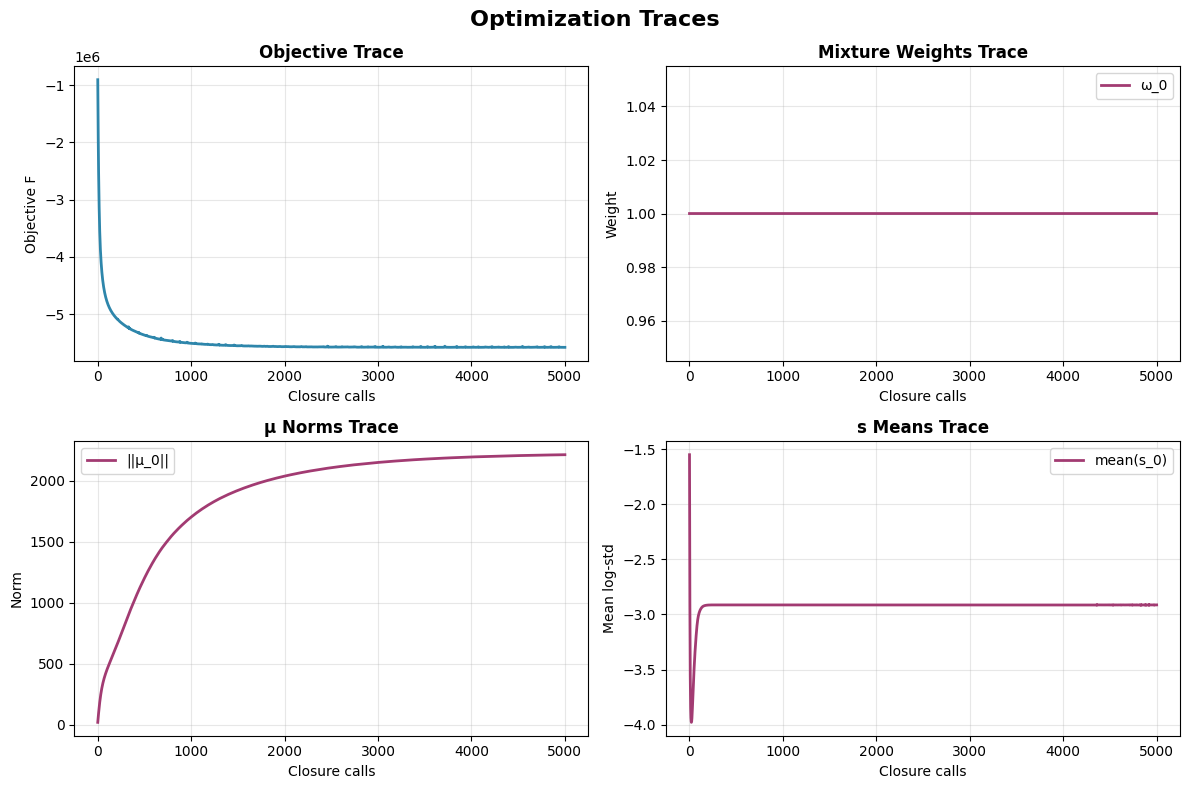

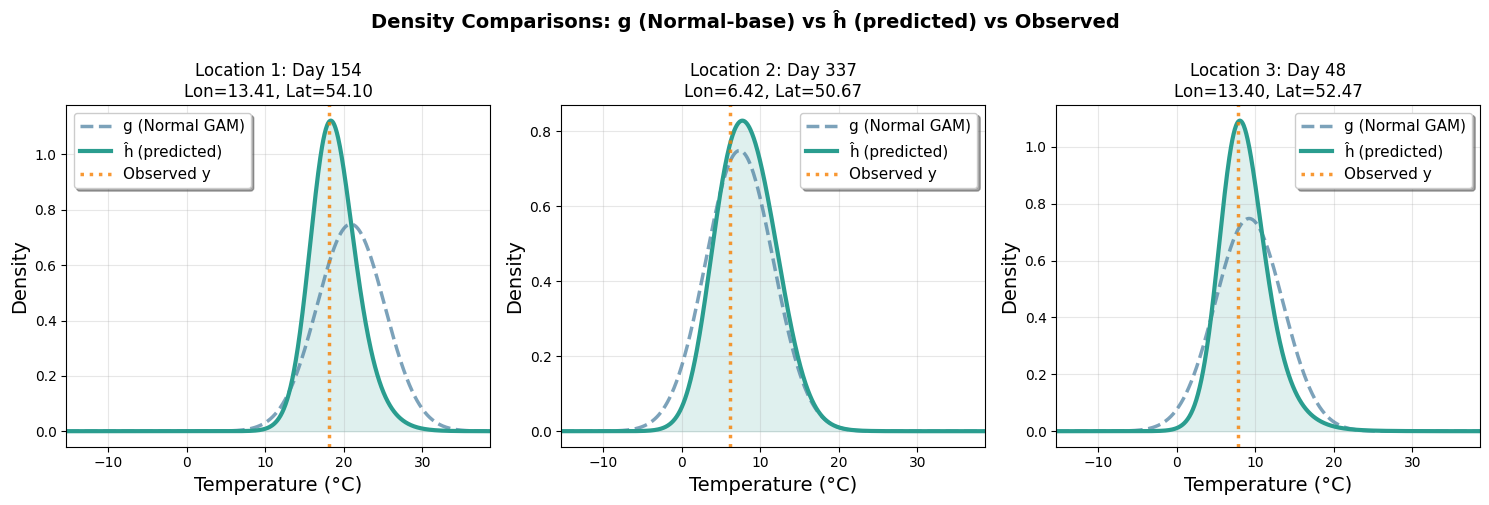

In [15]:
# ============================
# Group Figure 1: Optimization Traces (2×2 layout)
# ============================

fig1, axes1 = plt.subplots(2, 2, figsize=(12, 8))

# Objective trace
axes1[0,0].plot(range(1, len(trace["F"])+1), trace["F"], color='#2E86AB', linewidth=2)
axes1[0,0].set_xlabel("Closure calls")
axes1[0,0].set_ylabel("Objective F")
axes1[0,0].set_title("Objective Trace", fontweight='bold')
axes1[0,0].grid(True, alpha=0.3)

# Mixture weights trace
W = np.stack(trace["w"])  # shape [T, C]
colors_weights = ['#A23B72', '#F18F01', '#6A0572', '#AB83A1', '#F08A5D', '#B83B5E', '#6A0572', '#C0E218', '#3F88C5', '#F2545B']
for k in range(W.shape[1]):
    axes1[0,1].plot(range(1, len(trace["F"])+1), W[:, k], label=f"ω_{k}", color=colors_weights[k], linewidth=2)
axes1[0,1].set_xlabel("Closure calls")
axes1[0,1].set_ylabel("Weight")
axes1[0,1].set_title("Mixture Weights Trace", fontweight='bold')
axes1[0,1].legend()
axes1[0,1].grid(True, alpha=0.3)

# μ norms trace
MU = np.stack(trace["mu_norm"])  # [T, C]
for k in range(MU.shape[1]):
    axes1[1,0].plot(range(1, len(trace["F"])+1), MU[:, k], label=f"||μ_{k}||", color=colors_weights[k], linewidth=2)
axes1[1,0].set_xlabel("Closure calls")
axes1[1,0].set_ylabel("Norm")
axes1[1,0].set_title("μ Norms Trace", fontweight='bold')
axes1[1,0].legend()
axes1[1,0].grid(True, alpha=0.3)

# s means trace
S = np.stack(trace["s_mean"])  # [T, C]
for k in range(S.shape[1]):
    axes1[1,1].plot(range(1, len(trace["F"])+1), S[:, k], label=f"mean(s_{k})", color=colors_weights[k], linewidth=2)
axes1[1,1].set_xlabel("Closure calls")
axes1[1,1].set_ylabel("Mean log-std")
axes1[1,1].set_title("s Means Trace", fontweight='bold')
axes1[1,1].legend()
axes1[1,1].grid(True, alpha=0.3)

plt.suptitle('Optimization Traces', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig("optimization_traces_weather.pdf", dpi=300, bbox_inches="tight")
plt.show()

# ============================
# Group Figure 2: Density Comparisons (1×3 layout)
# Comparing: g_tilde (Normal GAM), ĥ (predicted), and observed y
# ============================

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

random_indexes = torch.randperm(x_test.size(0), generator=torch.Generator())[[12, 123, 1234]]  # select 3 random indexes for test points
x_values = [x_test[random_indexes[0],:].cpu().numpy(), x_test[random_indexes[1],:].cpu().numpy(), x_test[random_indexes[2],:].cpu().numpy()]
y_values = [y_test[random_indexes[0]].cpu().numpy(), y_test[random_indexes[1]].cpu().numpy(), y_test[random_indexes[2]].cpu().numpy()]

# Define colors for different components
color_g = '#E63946'          # Red for g (t-distribution)
color_g_tilde = '#457B9D'    # Blue for g_tilde (Normal GAM)
color_h_hat = '#2A9D8F'      # Green for ĥ (predicted)
color_obs = '#F77F00'        # Orange for observed y

for i, (ax, x_star) in enumerate(zip(axes2, x_values)):
    # Use standardized values for prediction
    y_grid, g_vals, g_tilde_vals, h_hat, _, _ = model.predict_density(x_star, y_all.min(), y_all.max(), M=1000)


    # convert to original scale for display only 
    # x_star_original = x_star * x_std + x_mean
    # # if inlucde map, apply the inverse of map X = (2 / (1+np.exp(-X))) - 1
    x_star_original = -np.log(2/(x_star+1)-1) * x_std + x_mean

    y_grid_original = y_grid * y_std + y_mean
    y_observed_original = y_values[i] * y_std + y_mean

    # Convert normalized time to day number within filtered range
    t_normalized = x_star_original[0]  # Time value in [0,1] for filtered data
    date_range_days = (df.index.max() - df.index.min()).days
    day_number = int(t_normalized * date_range_days)

    # Plot g_tilde (Normal base) and predicted density only
    ax.plot(y_grid_original, g_tilde_vals, '--', color=color_g_tilde, linewidth=2.5, alpha=0.7, label='g (Normal GAM)')
    ax.plot(y_grid_original, h_hat, '-', color=color_h_hat, linewidth=3, label='ĥ (predicted)')
    ax.axvline(y_observed_original, color=color_obs, linestyle=':', linewidth=2.5, alpha=0.8, label='Observed y')
    
    # Styling
    ax.set_xlabel('Temperature (°C)', fontsize=14)
    ax.set_ylabel('Density', fontsize=14)
    ax.set_title(f'Location {i+1}: Day {day_number}\nLon={x_star_original[1]:.2f}, Lat={x_star_original[2]:.2f}', fontsize=12)
    ax.legend(fontsize=11, frameon=True, fancybox=True, shadow=True, loc='best')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(y_grid_original.min(), y_grid_original.max())
    
    # Add subtle background fill under the predicted density curve
    ax.fill_between(y_grid_original, 0, h_hat, alpha=0.15, color=color_h_hat)

plt.suptitle('Density Comparisons: g (Normal-base) vs ĥ (predicted) vs Observed', 
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig("density_comparisons_weather_gpu.pdf", dpi=300, bbox_inches="tight")
plt.show()


In [16]:
# # use x_test and y_test to observe empirical performance of the density estimates \hat{h} and g_tilde

estimated_log_density_vals = 0
base_tilde_log_density_vals = 0


for i in range(len(x_test)):
    x_star = x_test[i].cpu().numpy()
    y_star = float(y_test[i].cpu().numpy().item())
    yg, gg, gg_tilde, hhat, _, _ = model.predict_density(x_star, y_min=y_all.min(), y_max=y_all.max(), M=1000)

    # Estimated log density at (x_star, y_star)
    # Interpolate to find the estimated density at y_star
    hhat_interp = np.interp(y_star, yg, hhat)
    log_hhat_star = np.log(hhat_interp)  # Add small constant to avoid log(0)
    estimated_log_density_vals += log_hhat_star
    
    # Base model g_tilde (Normal GAM) log density at (x_star, y_star)
    g_tilde_interp = np.interp(y_star, yg, gg_tilde)
    log_g_tilde_star = np.log(g_tilde_interp)  # Add small constant to avoid log(0)
    base_tilde_log_density_vals += log_g_tilde_star


    

print(f"Estimated Log Density (ĥ): {estimated_log_density_vals:.4f}")
print(f"Base Model Log Density (g̃, Normal): {base_tilde_log_density_vals:.4f}")


Estimated Log Density (ĥ): -11100.2877
Base Model Log Density (g̃, Normal): -13071.9185


In [17]:
# Pickle-save the optimized `model`
import pickle
with open("optimized_model_weather.pkl", "wb") as f:
    pickle.dump(model, f)


In [18]:
# Function to compute mean and credible intervals for base model g (t-distribution)
def get_base_g_stats(x_star):
    """
    Get mean and 95% credible interval for base model g (t-distribution).
    Uses scipy.stats.student_t.ppf for quantiles.
    
    Parameters:
    - x_star: array-like, shape (3,), containing [t, lon, lat] (standardized)
    
    Returns:
    - mu, lower, upper: mean and 95% CI bounds
    """
    x_star = np.array(x_star).reshape(1, -1)
    
    # Get mean from GAM
    mu = gam.predict(x_star)[0]
    
    # Get quantiles from t-distribution
    lower = student_t.ppf(0.025, DF, loc=mu, scale=SCALE_T)
    upper = student_t.ppf(0.975, DF, loc=mu, scale=SCALE_T)
    
    return mu, lower, upper


# Function to compute mean and credible intervals for base model g_tilde (Normal GAM)
def get_base_g_tilde_stats(x_star):
    """
    Get mean and 95% credible interval for base model g_tilde (Normal GAM).
    Uses scipy.stats.norm.ppf for quantiles with ORIGINAL_SIGMA_NORMAL (unscaled).
    
    Parameters:
    - x_star: array-like, shape (3,), containing [t, lon, lat] (standardized)
    
    Returns:
    - mu, lower, upper: mean and 95% CI bounds
    """
    from scipy.stats import norm
    x_star = np.array(x_star).reshape(1, -1)
    
    # Get mean from GAM
    mu = gam.predict(x_star)[0]
    
    # Get quantiles from normal distribution with ORIGINAL_SIGMA_NORMAL (unscaled)
    lower = norm.ppf(0.025, loc=mu, scale=ORIGINAL_SIGMA_NORMAL)
    upper = norm.ppf(0.975, loc=mu, scale=ORIGINAL_SIGMA_NORMAL)
    
    return mu, lower, upper


# Function to sample from the base model g_tilde (Normal GAM)
def sample_from_base_model(x_star, n_samples=1000):
    """
    Generate samples from the Normal GAM base model g_tilde at a given location/time.
    Uses ORIGINAL_SIGMA_NORMAL (unscaled).
    
    Parameters:
    - x_star: array-like, shape (3,), containing [t, lon, lat] (standardized)
    - n_samples: int, number of samples to generate
    
    Returns:
    - samples: array of sampled temperatures
    """
    x_star = np.array(x_star).reshape(1, -1)
    
    # Get mean from GAM
    mu = gam.predict(x_star)[0]
    
    # Sample from normal distribution with ORIGINAL_SIGMA_NORMAL (unscaled)
    samples = np.random.normal(loc=mu, scale=ORIGINAL_SIGMA_NORMAL, size=n_samples)
    
    return samples


# Function to sample from the updated model (for credible intervals)
def sample_from_updated_model(x_star, n_samples=1000, y_min=None, y_max=None, M=500):
    """
    Generate samples (Inverse transform sampling) from the updated GP density model at a given location/time.
    
    Parameters:
    - x_star: array-like, shape (3,), containing [t, lon, lat]
    - n_samples: int, number of samples to generate
    - y_min, y_max: float, range for temperature grid (if None, use reasonable defaults)
    - M: int, number of grid points for density evaluation
    
    Returns:
    - samples: array of sampled temperatures
    """
    x_star = np.array(x_star)
    
    # Get density predictions
    y_grid, g_vals, g_tilde_vals, h_hat, _, _ = model.predict_density(
        x_star, y_min=y_min, y_max=y_max, M=M
    )
    
    # Normalize the density to ensure it's a proper probability distribution
    dy = y_grid[1] - y_grid[0]
    h_hat_norm = h_hat / (np.trapz(h_hat, dx=dy))
    
    # Cumulative distribution function
    cdf = np.cumsum(h_hat_norm) * dy
    cdf = np.clip(cdf, 0, 1)  # ensure it's properly bounded
    
    # Generate uniform random samples and use inverse transform sampling
    np.random.seed(42)  # for reproducibility
    u = np.random.uniform(0, 1, n_samples)
    
    # Interpolate to get temperature samples
    samples = np.interp(u, cdf, y_grid)
    
    return samples


/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_33586/1041184509.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_33586/1041184509.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_y = np.trapz(yg * h_hat_norm, dx=dy)


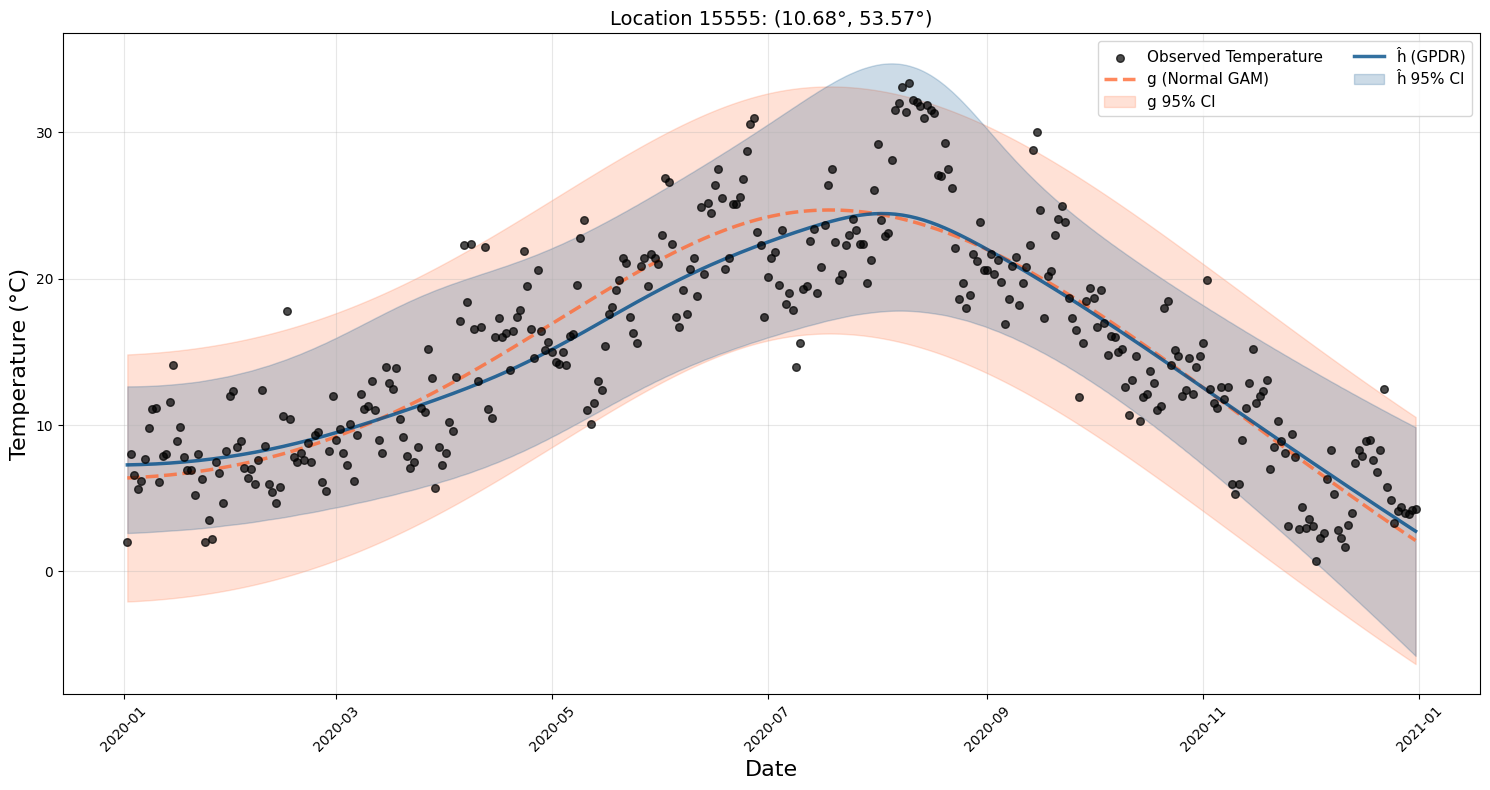

/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_33586/1041184509.py:55: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_33586/1041184509.py:58: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_y = np.trapz(yg * h_hat_norm, dx=dy)


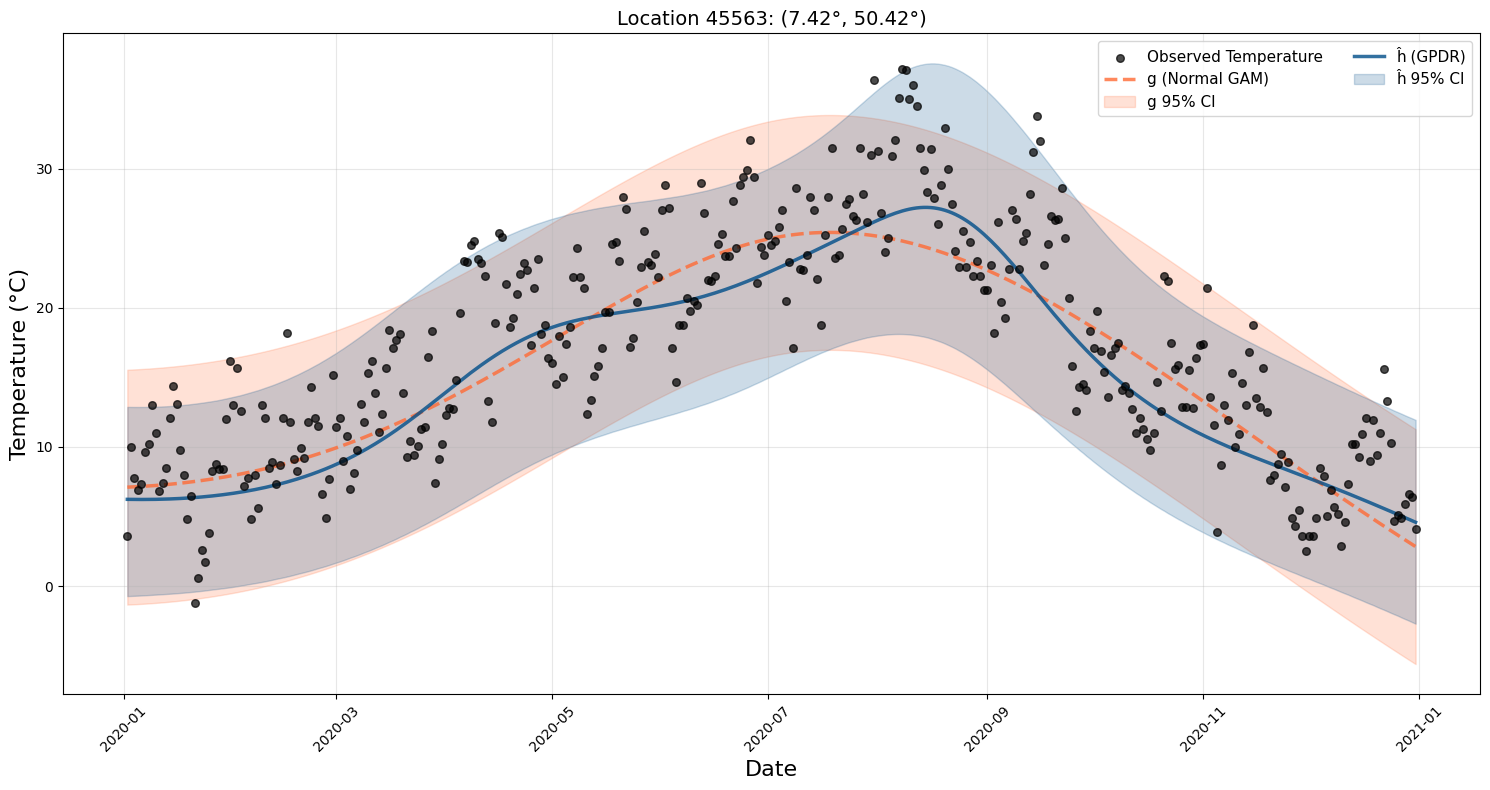

In [19]:
# Time series comparison for two locations: 45563 (7.4, 50.4) and 15555 (10.6, 53.5)
from scipy.stats import norm

for location_idx in [15555, 45563]:
    selected_location = df.iloc[location_idx]
    selected_lon = selected_location['longitude']
    selected_lat = selected_location['latitude']

    # Get data points at selected location
    location_mask = (np.abs(df['longitude'] - selected_lon) < 0.01) & (np.abs(df['latitude'] - selected_lat) < 0.01)
    location_data = df[location_mask].copy()

    if len(location_data) < 10:
        distances = np.sqrt((df['longitude'] - selected_lon)**2 + (df['latitude'] - selected_lat)**2)
        closest_indices = np.argsort(distances)[:100]
        location_data = df.iloc[closest_indices].copy()

    location_data = location_data.sort_values('t')
    X_loc_original = location_data[['t', 'longitude', 'latitude']].values
    y_loc_original = location_data['temperature'].values


    X_loc = (X_loc_original - x_mean) / x_std
    X_loc = 2/(1+np.exp(-X_loc)) - 1 
    y_loc = (y_loc_original - y_mean) / y_std

    # Base model g_tilde (Normal GAM) predictions only
    mu_g_tilde = []
    lower_g_tilde = []
    upper_g_tilde = []
    
    # Updated model predictions
    mu_updated = []
    lower_updated = []
    upper_updated = []

    for i, (t_val, lon_val, lat_val) in enumerate(X_loc):
        x_star = np.array([t_val, lon_val, lat_val])
        
        # Get g_tilde (Normal GAM) stats only
        mu, lower, upper = get_base_g_tilde_stats(x_star)
        mu_g_tilde.append(mu)
        lower_g_tilde.append(lower)
        upper_g_tilde.append(upper)
        
        # Get updated model stats using analytical density-based approach
        try:
            # Get density predictions
            yg, gg, gg_tilde, hhat, _, _ = model.predict_density(
                x_star, y_min=y_all.min().item()-20, y_max=y_all.max().item()+20, M=1000
            )
            
            # Normalize density
            dy = yg[1] - yg[0]
            h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
            
            # Analytical expectation: E[Y|X] = ∫ y * h(y|x) dy
            mean_y = np.trapz(yg * h_hat_norm, dx=dy)
            mu_updated.append(mean_y)
            
            # Compute credible intervals using CDF
            cdf = np.cumsum(h_hat_norm) * dy
            cdf = np.clip(cdf, 0, 1)
            
            lower_quantile = np.interp(0.025, cdf, yg)
            upper_quantile = np.interp(0.975, cdf, yg)
            lower_updated.append(lower_quantile)
            upper_updated.append(upper_quantile)
        except:
            # Fallback to g_tilde if density prediction fails
            mu_updated.append(mu_g_tilde[-1])
            lower_updated.append(lower_g_tilde[-1])
            upper_updated.append(upper_g_tilde[-1])

    mu_g_tilde = np.array(mu_g_tilde)
    lower_g_tilde = np.array(lower_g_tilde)
    upper_g_tilde = np.array(upper_g_tilde)
    
    mu_updated = np.array(mu_updated)
    lower_updated = np.array(lower_updated)
    upper_updated = np.array(upper_updated)

    mu_g_tilde_original = mu_g_tilde * y_std + y_mean
    lower_g_tilde_original = lower_g_tilde * y_std + y_mean
    upper_g_tilde_original = upper_g_tilde * y_std + y_mean
    
    mu_updated_original = mu_updated * y_std + y_mean
    lower_updated_original = lower_updated * y_std + y_mean
    upper_updated_original = upper_updated * y_std + y_mean

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(15, 8))

    ax.scatter(location_data.index, y_loc_original, alpha=0.7, s=30, color='black', 
              label='Observed Temperature', zorder=5)

    # Base model g_tilde (Normal GAM) only - Orange color for distinction
    ax.plot(location_data.index, mu_g_tilde_original, '--', linewidth=2.5, color='#FF6B35',
            label='g (Normal GAM)', alpha=0.8)
    ax.fill_between(location_data.index, 
                    lower_g_tilde_original, 
                    upper_g_tilde_original, 
                    alpha=0.2, color='#FF6B35', label='g 95% CI')

    # Updated model (GPDR) - Teal color for distinction
    ax.plot(location_data.index, mu_updated_original, '-', linewidth=2.5, color='#004E89',
            label='ĥ (GPDR)', alpha=0.8)
    ax.fill_between(location_data.index, 
                    lower_updated_original, 
                    upper_updated_original, 
                    alpha=0.2, color='#004E89', label='ĥ 95% CI')

    ax.set_xlabel('Date', fontsize=16)
    ax.set_ylabel('Temperature (°C)', fontsize=16)
    ax.set_title(f'Location {location_idx}: ({selected_lon:.2f}°, {selected_lat:.2f}°)', fontsize=14)
    ax.legend(fontsize=11, loc='upper right', ncol=2)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    plt.tight_layout()
    plt.savefig(f"time_effect_weather_gpu_{location_idx}.pdf", dpi=300, bbox_inches="tight")
    plt.show()

Observed data points at fixed time (day=51th): 458 locations
Observed temperature range: [-7.5, 10.8]°C, mean: 7.3°C
Below 0°C count: 5 | Above 0°C count: 453
g (Normal GAM) predictions: [6.0, 9.9]°C, mean: 8.5°C
g uncertainty: 4.31°C (constant)
Computing ĥ (GPDR) predictions via sampling...


/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_33586/1260685461.py:97: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_hat_norm = h_hat / (np.trapz(h_hat, dx=dy))


ĥ (GPDR) predictions: [5.4, 10.4]°C, mean: 8.4°C
ĥ uncertainty: [1.98, 6.26]°C (spatially varying)

=== CREATING SPATIAL VISUALIZATION ===
Temperature color mapping: min=-7.5°C, p5=4.3°C, median=7.7°C, p95=9.5°C, max=10.8°C
GPDR uncertainty color range: [1.90, 6.28]°C


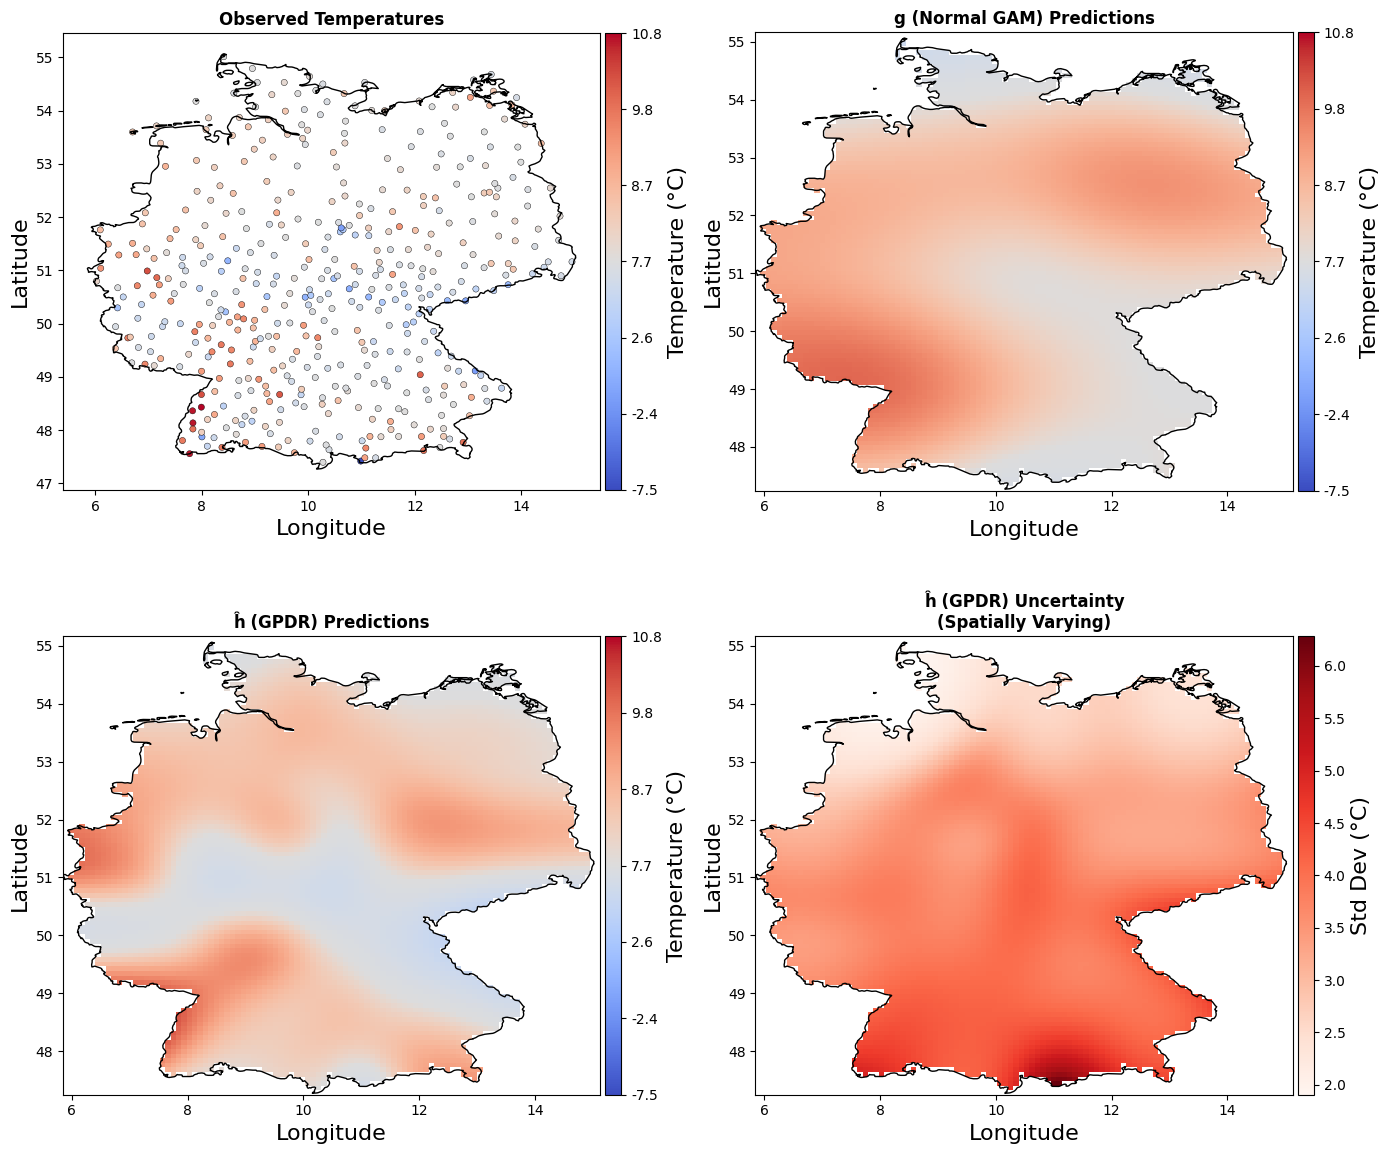

In [20]:
%matplotlib inline
from mpl_toolkits.axes_grid1 import make_axes_locatable
# SPATIAL ANALYSIS: Fixed time, varying locations only
# Comparing: Observed temperatures, g̃ (Normal GAM), ĥ (GPDR), and ĥ uncertainty
index_day = 51
fixed_time = df["t"].unique()[index_day-1]  # Single fixed time point throughout entire analysis

# Step 1: Get observed data at the fixed time
obs_data = df[df["t"]==fixed_time].copy()

# Step 2: Select diverse locations for analysis (spatial stratification)
lons_all = obs_data['longitude'].values
lats_all = obs_data['latitude'].values
temps_obs_all = obs_data['temperature'].values

lons = lons_all
lats = lats_all
temps_obs = temps_obs_all

print(f"Observed data points at fixed time (day={index_day}th): {len(temps_obs)} locations")
print(f"Observed temperature range: [{temps_obs.min():.1f}, {temps_obs.max():.1f}]°C, mean: {temps_obs.mean():.1f}°C")
print(f"Below 0°C count: {(temps_obs < 0).sum()} | Above 0°C count: {(temps_obs >= 0).sum()}")

# Step 3: Model predictions at fixed time, varying locations

# Create input: fixed time for all locations (original scale)
X_fixed_time_original = np.column_stack([
    np.full(len(lons), fixed_time),  # Same fixed time for ALL locations
    lons,                            # Different longitudes
    lats                             # Different latitudes
])

# Standardize input for model predictions and apply the map if model was trained on mapped data
X_fixed_time = (X_fixed_time_original - x_mean) / x_std
X_fixed_time = 2/(1+np.exp(-X_fixed_time)) - 1  # Apply map to [-1,1] if model was trained on mapped data

# g_tilde (Normal GAM) predictions at station points
mu_g_tilde = gam.predict(X_fixed_time)
sigma_g_tilde = ORIGINAL_SIGMA_NORMAL  # Constant uncertainty from Normal GAM (original, not scaled)

mu_g_tilde_original = mu_g_tilde * y_std + y_mean
sigma_g_tilde_original = sigma_g_tilde * y_std

print(f"g (Normal GAM) predictions: [{mu_g_tilde_original.min():.1f}, {mu_g_tilde_original.max():.1f}]°C, mean: {mu_g_tilde_original.mean():.1f}°C")
print(f"g uncertainty: {sigma_g_tilde_original:.2f}°C (constant)")

# Updated model predictions via sampling at station points
print("Computing ĥ (GPDR) predictions via sampling...")
mu_updated = []
sigma_updated = []

for i, (lon, lat) in enumerate(zip(lons, lats)):
    x_star_original = np.array([fixed_time, lon, lat])
    # apply standardization and map if model was trained on mapped data
    x_star = (x_star_original - x_mean) / x_std
    x_star = 2/(1+np.exp(-x_star)) - 1  # Sample from updated model to get mean and std

    samples = sample_from_updated_model(x_star, n_samples=500, y_min=y_all.min().item(), y_max=y_all.max().item())
    mu_updated.append(np.mean(samples))
    sigma_updated.append(np.std(samples))

mu_updated = np.array(mu_updated)
sigma_updated = np.array(sigma_updated)

# Convert to original scale
mu_updated_original = mu_updated * y_std + y_mean
sigma_updated_original = sigma_updated * y_std

print(f"ĥ (GPDR) predictions: [{mu_updated_original.min():.1f}, {mu_updated_original.max():.1f}]°C, mean: {mu_updated_original.mean():.1f}°C")
print(f"ĥ uncertainty: [{sigma_updated_original.min():.2f}, {sigma_updated_original.max():.2f}]°C (spatially varying)")

# Step 4: Create spatial visualization
print("\n=== CREATING SPATIAL VISUALIZATION ===")

# Create grid for heatmap visualization
lon_range = lons.max() - lons.min()
lat_range = lats.max() - lats.min()
lon_grid = np.linspace(lons.min() - 0.02*lon_range, lons.max() + 0.02*lon_range, 100)
lat_grid = np.linspace(lats.min() - 0.02*lat_range, lats.max() + 0.02*lat_range, 100)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# Apply Germany boundary mask first to skip outside points
x_flat = lon_mesh.ravel()
y_flat = lat_mesh.ravel()
xy = np.column_stack([x_flat, y_flat])

outside = np.ones(xy.shape[0], dtype=bool)
for geom in gdf.geometry:
    if isinstance(geom, Polygon):
        inside_poly = points_in_polygon_path(xy, geom)
        outside &= ~inside_poly  
    elif isinstance(geom, MultiPolygon):
        inside_any = np.zeros(xy.shape[0], dtype=bool)
        for part in geom.geoms:
            inside_any |= points_in_polygon_path(xy, part)
        outside &= ~inside_any
    else:
        continue

mask = outside.reshape(lon_mesh.shape)

# g̃ (Normal GAM) predictions on grid (original scale grid, standardize for prediction)
X_grid_original = np.column_stack([np.full(lon_mesh.size, fixed_time), lon_mesh.ravel(), lat_mesh.ravel()])
# standardize and apply map if model was trained on mapped data
X_grid = (X_grid_original - x_mean) / x_std
X_grid = 2/(1+np.exp(-X_grid)) - 1  # Apply map to [-1,1] if model was trained on mapped data
mu_g_tilde_grid = gam.predict(X_grid).reshape(lon_mesh.shape)
sigma_g_tilde_grid = np.full_like(mu_g_tilde_grid, ORIGINAL_SIGMA_NORMAL)

# Convert to original scale
mu_g_tilde_grid_original = mu_g_tilde_grid * y_std + y_mean
sigma_g_tilde_grid_original = sigma_g_tilde_grid * y_std

# ĥ (GPDR) predictions on grid (sample-based, compute only within boundary)
mu_updated_grid = np.full(lon_mesh.shape, np.nan)
sigma_updated_grid = np.full(lon_mesh.shape, np.nan)
valid_idx = np.where(~mask.ravel())[0]
n_samples_grid = 100

for k, idx in enumerate(valid_idx):
    samples = sample_from_updated_model(X_grid[idx], n_samples=n_samples_grid, y_min=y_all.min().item(), y_max=y_all.max().item())
    mu_updated_grid.ravel()[idx] = np.mean(samples)
    sigma_updated_grid.ravel()[idx] = np.std(samples)

# Convert to original scale
mu_updated_grid_original = mu_updated_grid * y_std + y_mean
sigma_updated_grid_original = sigma_updated_grid * y_std

# Mask arrays for plotting
mu_g_tilde_masked = np.ma.array(mu_g_tilde_grid_original, mask=mask)
mu_updated_masked = np.ma.array(mu_updated_grid_original, mask=mask)
sigma_g_tilde_masked = np.ma.array(sigma_g_tilde_grid_original, mask=mask)
sigma_updated_masked = np.ma.array(sigma_updated_grid_original, mask=mask)

# 4-panel spatial comparison plot (2x2 grid): Observed, g̃, ĥ predictions, and ĥ uncertainty
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Adaptive temperature color range based on percentiles to enhance main data range
# Use percentiles to focus color variation on the bulk of the data
temp_p5 = np.percentile(temps_obs, 5)   # 5th percentile
temp_p95 = np.percentile(temps_obs, 95)  # 95th percentile
temp_median = np.median(temps_obs)

# Create a centered normalization that emphasizes the main data range
# TwoSlopeNorm allows asymmetric scaling around the center
from matplotlib.colors import TwoSlopeNorm
temp_norm = TwoSlopeNorm(vmin=temps_obs.min(), vcenter=temp_median, vmax=temps_obs.max())

print(f"Temperature color mapping: min={temps_obs.min():.1f}°C, p5={temp_p5:.1f}°C, median={temp_median:.1f}°C, p95={temp_p95:.1f}°C, max={temps_obs.max():.1f}°C")

# Uncertainty color range - use only GPDR uncertainty range for better visual contrast
sigma_vmin = np.nanmin(sigma_updated_masked)
sigma_vmax = np.nanmax(sigma_updated_masked)
print(f"GPDR uncertainty color range: [{sigma_vmin:.2f}, {sigma_vmax:.2f}]°C")

# Panel 1: Observed temperatures at fixed time (scatter of stations)
ax1 = axes[0, 0]
sc1 = ax1.scatter(lons, lats, c=temps_obs, cmap='coolwarm', norm=temp_norm, s=20, edgecolors='k', linewidths=0.3)
gdf.boundary.plot(ax=ax1, color='k', linewidth=1.0)
ax1.set_title(f'Observed Temperatures', fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=16)
ax1.set_ylabel('Latitude', fontsize=16)
ax1.set_aspect('equal')

# Colorbar for panel 1
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes("right", size="3%", pad=0.05)
cb1 = fig.colorbar(sc1, cax=cax1)
cb1.set_label('Temperature (°C)', fontsize=16)

# Set evenly spaced ticks for all temperature colorbars
norm_positions = np.linspace(0, 1, 7)  # 7 evenly spaced positions visually
temp_tick_values = [temp_norm.inverse(p) for p in norm_positions]
cb1.set_ticks(temp_tick_values)
cb1.set_ticklabels([f'{t:.1f}' for t in temp_tick_values])

# Panel 2: g̃ (Normal GAM) predictions (heatmap on grid)
ax2 = axes[0, 1]
im2 = ax2.imshow(mu_g_tilde_masked, extent=[lon_mesh.min(), lon_mesh.max(), lat_mesh.min(), lat_mesh.max()], 
                 cmap='coolwarm', norm=temp_norm, aspect='equal', origin='lower')
gdf.boundary.plot(ax=ax2, color='k', linewidth=1.0)
ax2.set_title('g (Normal GAM) Predictions', fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=16)
ax2.set_ylabel('Latitude', fontsize=16)
ax2.set_aspect('equal')

# Colorbar for panel 2
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes("right", size="3%", pad=0.05)
cb2 = fig.colorbar(im2, cax=cax2)
cb2.set_label('Temperature (°C)', fontsize=16)
cb2.set_ticks(temp_tick_values)
cb2.set_ticklabels([f'{t:.1f}' for t in temp_tick_values])

# Panel 3: Updated model predictions (heatmap on grid)
ax3 = axes[1, 0]
im3 = ax3.imshow(mu_updated_masked, extent=[lon_mesh.min(), lon_mesh.max(), lat_mesh.min(), lat_mesh.max()], 
                 cmap='coolwarm', norm=temp_norm, aspect='equal', origin='lower')
gdf.boundary.plot(ax=ax3, color='k', linewidth=1.0)
ax3.set_title('ĥ (GPDR) Predictions', fontweight='bold')
ax3.set_xlabel('Longitude', fontsize=16)
ax3.set_ylabel('Latitude', fontsize=16)
ax3.set_aspect('equal')

# Colorbar for panel 3
divider3 = make_axes_locatable(ax3)
cax3 = divider3.append_axes("right", size="3%", pad=0.05)
cb3 = fig.colorbar(im3, cax=cax3)
cb3.set_label('Temperature (°C)', fontsize=16)
cb3.set_ticks(temp_tick_values)
cb3.set_ticklabels([f'{t:.1f}' for t in temp_tick_values])

# Panel 4: Updated model uncertainty (spatially varying)
ax4 = axes[1, 1]
im4 = ax4.imshow(sigma_updated_masked, extent=[lon_mesh.min(), lon_mesh.max(), lat_mesh.min(), lat_mesh.max()], 
                 cmap='Reds', vmin=sigma_vmin, vmax=sigma_vmax, aspect='equal', origin='lower')
gdf.boundary.plot(ax=ax4, color='k', linewidth=1.0)
ax4.set_title('ĥ (GPDR) Uncertainty\n(Spatially Varying)', fontweight='bold')
ax4.set_xlabel('Longitude', fontsize=16)
ax4.set_ylabel('Latitude', fontsize=16)
ax4.set_aspect('equal')

# Colorbar for panel 4 (consistent with panel 3)
divider4 = make_axes_locatable(ax4)
cax4 = divider4.append_axes("right", size="3%", pad=0.05)
cb4 = fig.colorbar(im4, cax=cax4)
cb4.set_label('Std Dev (°C)', fontsize=16)

plt.tight_layout()

plt.savefig("spatial_analysis_fixed_time_only.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [21]:
# === Prediction Error Summary at station points for spatial analysis ===
def metrics(y_true, y_pred):
    mae = float(np.mean(np.abs(y_pred - y_true)))
    rmse = float(np.sqrt(np.mean((y_pred - y_true)**2)))
    return mae, rmse

# Compute g (t-distribution) predictions
mu_g = []
for i in range(len(X_fixed_time)):
    x_star = X_fixed_time[i]
    mu, _, _ = get_base_g_stats(x_star)
    mu_g.append(mu)
mu_g = np.array(mu_g)
mu_g_original = mu_g * y_std + y_mean

# Compute metrics for all three models
g_mae, g_rmse = metrics(temps_obs, mu_g_original)
g_tilde_mae, g_tilde_rmse = metrics(temps_obs, mu_g_tilde_original)
h_mae, h_rmse = metrics(temps_obs, mu_updated_original)

print("\n=== Prediction Error Summary ===")
print(f"g (t-dist)     -> MAE: {g_mae:.3f} °C | RMSE: {g_rmse:.3f} °C | Total Error: {np.sum(np.abs(mu_g_original - temps_obs)):.1f}")
print(f"g̃ (Normal GAM) -> MAE: {g_tilde_mae:.3f} °C | RMSE: {g_tilde_rmse:.3f} °C | Total Error: {np.sum(np.abs(mu_g_tilde_original - temps_obs)):.1f}")
print(f"ĥ (GPDR)       -> MAE: {h_mae:.3f} °C | RMSE: {h_rmse:.3f} °C | Total Error: {np.sum(np.abs(mu_updated_original - temps_obs)):.1f}")


=== Prediction Error Summary ===
g (t-dist)     -> MAE: 1.412 °C | RMSE: 2.155 °C | Total Error: 646.9
g̃ (Normal GAM) -> MAE: 1.412 °C | RMSE: 2.155 °C | Total Error: 646.9
ĥ (GPDR)       -> MAE: 1.262 °C | RMSE: 1.896 °C | Total Error: 578.1


In [22]:
# ============================
# Model Comparison Diagnostics with UNSTANDARDIZED Data
# ============================

# Define parameters
n_test = len(x_test)


# Initialize storage for diagnostics (in original scale) - 95% CI only
updated_predictions_orig = []
updated_intervals_orig_lower = []
updated_intervals_orig_upper = []

base_g_tilde_predictions_orig = []
base_g_tilde_intervals_orig_lower = []
base_g_tilde_intervals_orig_upper = []

y_obs_orig = []

for i in range(n_test):
    x_star_std = x_test[i].cpu().numpy()  # Standardized x
    y_star_std = float(y_test[i].cpu().numpy().item())  # Standardized y
    
    # Convert y back to original scale for observation
    y_star_orig = y_star_std * y_std + y_mean
    y_obs_orig.append(y_star_orig)
    
    # ==================
    # Updated Model (ĥ) - Density-based approach
    # ==================
    # Get density predictions (in standardized space)
    yg, gg, gg_tilde, hhat, _, _ = model.predict_density(
        x_star_std, y_min=y_all.min().item(), y_max=y_all.max().item(), M=1000
    )
    
    # Normalize density
    dy = yg[1] - yg[0]
    h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
    
    # Analytical expectation: E[Y|X] = ∫ y * h(y|x) dy (in standardized space)
    mean_y_std = np.trapz(yg * h_hat_norm, dx=dy)
    
    # Convert to original scale
    mean_y_orig = mean_y_std * y_std + y_mean
    updated_predictions_orig.append(mean_y_orig)
    
    # Compute 95% credible interval using CDF
    cdf = np.cumsum(h_hat_norm) * dy
    cdf = np.clip(cdf, 0, 1)
    
    lower_q = 0.025  # (1 - 0.95) / 2
    upper_q = 0.975  # 1 - 0.025
    lower_quantile_std = np.interp(lower_q, cdf, yg)
    upper_quantile_std = np.interp(upper_q, cdf, yg)
    
    # Convert to original scale
    lower_quantile_orig = lower_quantile_std * y_std + y_mean
    upper_quantile_orig = upper_quantile_std * y_std + y_mean
    updated_intervals_orig_lower.append(lower_quantile_orig)
    updated_intervals_orig_upper.append(upper_quantile_orig)
    
    # ==================
    # Base Model g̃ (Normal GAM) - using ORIGINAL_SIGMA_NORMAL (unscaled)
    # ==================
    x_star_std_reshape = np.array(x_star_std).reshape(1, -1)
    mu_std = gam.predict(x_star_std_reshape)[0]
    
    # Convert mean to original scale
    mu_orig = mu_std * y_std + y_mean
    base_g_tilde_predictions_orig.append(mu_orig)
    
    # Compute 95% interval using ORIGINAL_SIGMA_NORMAL (unscaled)
    lower_std = norm.ppf(0.025, loc=mu_std, scale=ORIGINAL_SIGMA_NORMAL)
    upper_std = norm.ppf(0.975, loc=mu_std, scale=ORIGINAL_SIGMA_NORMAL)
    
    # Convert to original scale
    lower_orig = lower_std * y_std + y_mean
    upper_orig = upper_std * y_std + y_mean
    base_g_tilde_intervals_orig_lower.append(lower_orig)
    base_g_tilde_intervals_orig_upper.append(upper_orig)

# Convert to numpy arrays
y_obs_orig = np.array(y_obs_orig)
updated_predictions_orig = np.array(updated_predictions_orig)
base_g_tilde_predictions_orig = np.array(base_g_tilde_predictions_orig)

updated_intervals_orig_lower = np.array(updated_intervals_orig_lower)
updated_intervals_orig_upper = np.array(updated_intervals_orig_upper)
base_g_tilde_intervals_orig_lower = np.array(base_g_tilde_intervals_orig_lower)
base_g_tilde_intervals_orig_upper = np.array(base_g_tilde_intervals_orig_upper)

# ==================
# Compute Diagnostics (in original temperature scale)
# ==================

# RMSE (Root Mean Squared Error) in °C
rmse_g_tilde_orig = np.sqrt(np.mean((base_g_tilde_predictions_orig - y_obs_orig)**2))
rmse_updated_orig = np.sqrt(np.mean((updated_predictions_orig - y_obs_orig)**2))

# ==================
# Display Results
# ==================
print("\n" + "="*70)
print("MODEL COMPARISON DIAGNOSTICS (Weather Data - ORIGINAL SCALE)")
print("="*70)

print(f"\nData Scale Information:")
print(f"   Observed test range: [{y_obs_orig.min():.2f}, {y_obs_orig.max():.2f}] °C")

print("\nRMSE (Root Mean Squared Error) in °C:")
print(f"   g̃ (Normal GAM): {rmse_g_tilde_orig:.4f} °C")
print(f"   ĥ (GPDR):       {rmse_updated_orig:.4f} °C")
print()

# Display 95% CI coverage and interval length
coverage_g_tilde = np.mean((y_obs_orig >= base_g_tilde_intervals_orig_lower) & 
                           (y_obs_orig <= base_g_tilde_intervals_orig_upper))
coverage_updated = np.mean((y_obs_orig >= updated_intervals_orig_lower) & 
                           (y_obs_orig <= updated_intervals_orig_upper))

avg_length_g_tilde = np.mean(base_g_tilde_intervals_orig_upper - base_g_tilde_intervals_orig_lower)
avg_length_updated = np.mean(updated_intervals_orig_upper - updated_intervals_orig_lower)

print(f"95% CI Coverage:")
print(f"   g̃ (Normal GAM): {coverage_g_tilde:.4f}")
print(f"   ĥ (GPDR):       {coverage_updated:.4f}")

print(f"\n95% CI Avg Width (°C):")
print(f"   g̃ (Normal GAM): {avg_length_g_tilde:.4f} °C")
print(f"   ĥ (GPDR):       {avg_length_updated:.4f} °C")

/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_33586/893307469.py:38: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  h_hat_norm = hhat / (np.trapz(hhat, dx=dy))
/var/folders/5q/r8dt0jb906xbzf494xwk97fw0000gn/T/ipykernel_33586/893307469.py:41: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  mean_y_std = np.trapz(yg * h_hat_norm, dx=dy)



MODEL COMPARISON DIAGNOSTICS (Weather Data - ORIGINAL SCALE)

Data Scale Information:
   Observed test range: [-15.30, 37.20] °C

RMSE (Root Mean Squared Error) in °C:
   g̃ (Normal GAM): 4.2602 °C
   ĥ (GPDR):       4.0282 °C

95% CI Coverage:
   g̃ (Normal GAM): 0.9551
   ĥ (GPDR):       0.9607

95% CI Avg Width (°C):
   g̃ (Normal GAM): 16.8838 °C
   ĥ (GPDR):       15.3801 °C


In [23]:
# # ============================
# # Part 1: Generate Hyperparameter Candidates with Median Heuristic Optimization
# # ============================
# from scipy.stats import qmc
# from scipy.spatial.distance import pdist, squareform
# import time

# # Define interpretable parameter ranges
# # Kernel variance: σ range → log(σ²)
# sigma_range = (0.01, 1.0)
# log_sigma2_range = (math.log(sigma_range[0]**2), math.log(sigma_range[1]**2))

# # Lengthscale in x: lx range → log(lx²)
# lx_range = (0.01, 1.0)
# log_lx2_range = (math.log(lx_range[0]**2), math.log(lx_range[1]**2))

# # Lengthscale in z: lz range → log(lz²)
# lz_range = (0.01, 1.0)
# log_lz2_range = (math.log(lz_range[0]**2), math.log(lz_range[1]**2))

# # Learning weight: log-scale range
# log_beta_range = (math.log(0.01), math.log(2000))

# # Inducing points: FIXED at 1000 (not part of search)
# m_induce_fixed = 1000

# # Generate initial LHS candidates
# n_candidates = 100
# sampler = qmc.LatinHypercube(d=4, seed=42)  # 4D: log_sigma2, log_lx2, log_lz2, beta
# lhs_samples = sampler.random(n=n_candidates)

# print(f"Generating {n_candidates} candidates using Latin Hypercube Sampling...")

# # LHS samples are already in [0, 1]^4, which is perfect for distance optimization
# # We'll work in normalized space, then convert to actual hyperparameters at the end
# candidates_normalized = lhs_samples.copy()  # Shape: (n_candidates, 4)

# print(f"✓ Created {len(candidates_normalized)} candidates from LHS\n")

# # Apply median heuristic to maximize minimal distance between candidates
# # Working in normalized [0, 1]^4 space ensures all dimensions are equally weighted
# print("Optimizing candidate locations using median heuristic...")
# print("  Goal: Maximize the minimal pairwise distance between candidates")
# print("  Working in normalized [0, 1]^4 space for fair distance metric\n")

# max_iterations = 50
# learning_rate = 0.01

# for iteration in range(max_iterations):
#     # Compute pairwise distances in normalized space
#     dists = squareform(pdist(candidates_normalized, 'euclidean'))
    
#     # Set diagonal to infinity to avoid self-distances
#     np.fill_diagonal(dists, np.inf)
    
#     # Find minimum distance for each point
#     min_dists = np.min(dists, axis=1)
    
#     # Current objective: median of minimal distances
#     current_median_min_dist = np.median(min_dists)
    
#     # Find points with smallest minimal distances (need most improvement)
#     worst_points = np.argsort(min_dists)[:n_candidates // 10]  # Improve worst 10%
    
#     # Move worst points away from their nearest neighbors
#     for idx in worst_points:
#         nearest_neighbor_idx = np.argmin(dists[idx])
#         direction = candidates_normalized[idx] - candidates_normalized[nearest_neighbor_idx]
#         direction_norm = np.linalg.norm(direction)
        
#         if direction_norm > 1e-8:
#             # Move in direction away from nearest neighbor
#             candidates_normalized[idx] += learning_rate * direction / direction_norm
    
#     # Project back to [0, 1]^4 (clip to valid normalized range)
#     candidates_normalized = np.clip(candidates_normalized, 0.0, 1.0)

# # Final distance statistics
# dists_final = squareform(pdist(candidates_normalized, 'euclidean'))
# np.fill_diagonal(dists_final, np.inf)
# min_dists_final = np.min(dists_final, axis=1)

# print(f"\n✓ Optimization complete!")
# print(f"  Median minimal distance: {np.median(min_dists_final):.4f}")
# print(f"  Mean minimal distance:   {np.mean(min_dists_final):.4f}")
# print(f"  Min minimal distance:    {np.min(min_dists_final):.4f}\n")

# # Now convert normalized [0, 1]^4 candidates to actual hyperparameter values
# print("Converting normalized candidates to hyperparameter space...")
# candidates = []

# for i in range(n_candidates):
#     # Extract normalized values
#     norm_log_sigma2 = candidates_normalized[i, 0]
#     norm_log_lx2 = candidates_normalized[i, 1]
#     norm_log_lz2 = candidates_normalized[i, 2]
#     norm_log_beta = candidates_normalized[i, 3]
    
#     # Scale to actual parameter ranges
#     log_sigma2 = log_sigma2_range[0] + norm_log_sigma2 * (log_sigma2_range[1] - log_sigma2_range[0])
#     log_lx2 = log_lx2_range[0] + norm_log_lx2 * (log_lx2_range[1] - log_lx2_range[0])
#     log_lz2 = log_lz2_range[0] + norm_log_lz2 * (log_lz2_range[1] - log_lz2_range[0])
#     log_beta = log_beta_range[0] + norm_log_beta * (log_beta_range[1] - log_beta_range[0])
#     beta = np.exp(log_beta)
    
#     candidates.append({
#         'log_sigma2': log_sigma2,
#         'log_lx2': log_lx2,
#         'log_lz2': log_lz2,
#         'beta': beta,
#         'm_induce': m_induce_fixed  # Fixed at 1000
#     })

# print(f"✓ Generated {len(candidates)} optimized hyperparameter candidates for cross-validation")


In [24]:
# # Save candidates for later use
# import pickle
# with open("hyperparameter_candidates_weather.pkl", "wb") as f:
#     pickle.dump(candidates, f)

In [25]:
# # load candidates
# with open("hyperparameter_candidates_weather.pkl", "rb") as f:
#     candidates = pickle.load(f)

In [26]:
# # ============================
# # Part 2: Cross-Validation Evaluation of Candidates
# # ============================

# import time
# import io
# import sys
# import contextlib
# import pickle
# from dataclasses import dataclass

# # Custom KernelParams class for CV that supports log_lx2 parameter
# @dataclass
# class KernelParamsCV:
#     log_sigma2: float
#     log_lx2: float
#     log_lz2: float
    
#     def get_lx2(self, device, dtype):
#         """Get lengthscale tensor on the correct device/dtype"""
#         # Create a vector with dim_x copies of log_lx2, same as original KernelParams
#         log_lx2_tensor = torch.tensor([self.log_lx2 for s in range(dim_x)], device=device, dtype=dtype)
#         return torch.exp(log_lx2_tensor)
    
#     @property
#     def sigma2(self): return math.exp(self.log_sigma2)
#     @property
#     def lx2(self):    return math.exp(self.log_lx2)
#     @property
#     def lz2(self):    return math.exp(self.log_lz2)


# def compute_inducing_points_from_x(x_train_fold, m_induce, device):
#     """
#     Compute inducing points using k-means clustering on x coordinates only.
#     Returns x-coordinates of cluster centers for inducing point grid.
    
#     This is extracted from LogisticGPMixtureDiag.__init__ to avoid redundant computation.
#     """
#     n_per_dim = int(round(m_induce ** (1/(dim_x+1))))
#     totalnum_xpoints = n_per_dim ** dim_x
    
#     # Perform k-means clustering on x coordinates
#     optimal_k = totalnum_xpoints
#     cluster_ids_x, cluster_centers = kmeans(
#         X=x_train_fold, num_clusters=optimal_k, distance='euclidean', device=device
#     )
    
#     # Extract cluster centers
#     points_allcluster = torch.zeros((0, dim_x), device=device, dtype=x_train_fold.dtype)
#     for u in range(optimal_k):
#         cluster_center = torch.tensor(cluster_centers[u], device=device, dtype=x_train_fold.dtype)
#         points_allcluster = torch.cat([points_allcluster, cluster_center.unsqueeze(0)], dim=0)
    
#     x_grid = points_allcluster[1:, :]  # remove initial zero row
    
#     return x_grid, n_per_dim


# def create_inducing_points_from_x_grid(x_grid, n_per_dim, device, dtype):
#     """
#     Create full (x,z) inducing points from x-grid and z-grid.
#     """
#     z_grid = torch.linspace(1e-5, 1-1e-5, n_per_dim, device=device, dtype=dtype)
    
#     # Create meshgrid for (x, z) inducing points
#     x_grid_expand = x_grid[:, None, :].expand(x_grid.size(0), n_per_dim, dim_x)
#     z_grid_expand = z_grid[None, :, None].expand(x_grid.size(0), n_per_dim, 1)
    
#     Vu = torch.cat([x_grid_expand, z_grid_expand], dim=2).reshape(x_grid.size(0)*n_per_dim, dim_x+1)
    
#     return Vu


# def create_model_with_precomputed_inducing(x_train_fold, y_train_fold, x_grid_precomputed, 
#                                             n_per_dim, kp, beta, device):
#     """
#     Create LogisticGPMixtureDiag model bypassing k-means by manually constructing it.
#     This completely avoids k-means clustering - saving massive time!
    
#     Args:
#         x_grid_precomputed: Pre-computed x-coordinates from k-means (shape: [n_x_points, dim_x])
#         n_per_dim: Number of grid points per dimension
#     """
#     # Create the full (x,z) inducing points grid from pre-computed x-grid
#     Vu_precomputed = create_inducing_points_from_x_grid(
#         x_grid_precomputed, n_per_dim, device, x_train_fold.dtype
#     )
    
#     # ============================================================
#     # Manually initialize model WITHOUT calling __init__ 
#     # This bypasses the k-means clustering completely!
#     # ============================================================
#     model = LogisticGPMixtureDiag.__new__(LogisticGPMixtureDiag)
#     nn.Module.__init__(model)  # Initialize as nn.Module
    
#     # Set basic attributes (from __init__)
#     model.x = x_train_fold.detach()
#     model.y = y_train_fold.detach()
#     model.n = x_train_fold.size(0)
#     model.C = 1  # Single component for CV
#     model.beta = beta
#     model.kern = RBF_SE_ARD(kp, device=device, dtype=x_train_fold.dtype)
    
#     # Transform to z and build training inputs V = (x, z)
#     z = to_z_from_y(model.y, model.x)
#     z = torch.clamp(z, 1e-5, 1-1e-5)
#     model.V = torch.cat([model.x, z.reshape(-1, 1)], dim=1)  # (n, dim_x + 1)
    
#     # Use pre-computed inducing points (NO K-MEANS!)
#     model.Vu = Vu_precomputed
#     model.m = model.Vu.size(0)
    
#     # Base model terms
#     model.g, model.gy, model.gyy = base_g_terms(model.y, model.x)
    
#     # Kernel blocks
#     model.K11uu = model.kern.delta_11(model.Vu, model.Vu)
#     model.K11uu_inv, model.K11uu_chol = chol_inv(model.K11uu)
#     model.A = model.kern.delta_11(model.V, model.Vu) @ model.K11uu_inv
#     model.B = model.kern.delta_21(model.V, model.Vu) @ model.K11uu_inv
#     model.A2 = model.A**2
#     model.A2T_g2_over_n = model.A2.T @ ((model.g**2) / model.n)
    
#     # Variational parameters
#     model.logits = nn.Parameter(torch.randn(model.C, device=device, dtype=x_train_fold.dtype))
#     model.mus = nn.Parameter(torch.randn(model.C, model.m, device=device, dtype=x_train_fold.dtype))
#     init_log_std = math.log(0.35)
#     model.s_params = nn.Parameter(torch.full((model.C, model.m), init_log_std, device=device, dtype=x_train_fold.dtype))
    
#     # Warm-start μ
#     model.warm_start_mu()
    
#     return model.to(device)


# def train_and_evaluate_model_cv(log_sigma2, log_lx2, log_lz2, beta, 
#                                   x_train_fold, y_train_fold, x_val_fold, y_val_fold,
#                                   x_grid_precomputed, n_per_dim):
#     """
#     Train model on training fold and evaluate log score on validation fold.
#     Uses pre-computed x-grid to avoid k-means clustering.
#     """
#     kp = KernelParamsCV(log_sigma2=log_sigma2, log_lx2=log_lx2, log_lz2=log_lz2)
    
#     try:
#         # Create model with pre-computed inducing points (bypasses k-means effectively)
#         model_cv = create_model_with_precomputed_inducing(
#             x_train_fold, y_train_fold, x_grid_precomputed, n_per_dim, kp, beta, device
#         )
        
#         optimizer_cv = optim.Adam(model_cv.parameters(), lr=0.5)
        
#         # Training loop - 5000 iterations to match main training
#         num_iterations = 5000
#         for iteration in range(num_iterations):
#             optimizer_cv.zero_grad()
#             F, info = model_cv.forward_objective()
#             F.backward()
#             optimizer_cv.step()
        
#         # Evaluate log score on validation fold
#         total_log_score = 0.0
        
#         for i in range(len(x_val_fold)):
#             x_star = x_val_fold[i, :].cpu().numpy()
#             y_star = float(y_val_fold[i].cpu().numpy().item())
            
#             # Predict density
#             y_grid, g_vals, g_tilde_vals, h_hat, _, _ = model_cv.predict_density(
#                 x_star, y_min=y_all.min(), y_max=y_all.max(), M=1000
#             )
            
#             # Interpolate to get ĥ(y_star|x_star)
#             hhat_interp = np.interp(y_star, y_grid, h_hat)
#             total_log_score += np.log(max(hhat_interp, 1e-12))
        
#         return total_log_score
#     except Exception as e:
#         print(f"\nError in CV: {e}")
#         import traceback
#         traceback.print_exc()
#         return None


# # ============================
# # Step 1: Prepare 3-fold cross-validation splits with subsampled validation sets
# # ============================
# n_train = len(x_train)
# fold_size = n_train // 3
# cv_seed = 42  # Random seed for reproducibility

# # Create 3-fold split
# cv_indices = torch.randperm(n_train, generator=torch.Generator().manual_seed(cv_seed))

# fold_indices = [
#     cv_indices[:fold_size],
#     cv_indices[fold_size:2*fold_size],
#     cv_indices[2*fold_size:]
# ]

# print("\n" + "="*70)
# print(f"3-fold cross-validation setup on {n_train} training samples")
# print(f"  Original fold sizes: {[len(fold) for fold in fold_indices]}")

# # Subsample validation sets to 1/3 of each fold (10% of total training data)
# val_subsample_fraction = 1.0 / 3.0
# val_generator = torch.Generator().manual_seed(cv_seed + 1)

# fold_combinations = [
#     ([0, 1], 2),  # Train on folds 0,1; validate on fold 2
#     ([0, 2], 1),  # Train on folds 0,2; validate on fold 1
#     ([1, 2], 0),  # Train on folds 1,2; validate on fold 0
# ]

# # Pre-define subsampled validation indices for each fold
# val_subsampled_indices = {}
# for train_fold_ids, val_fold_id in fold_combinations:
#     full_val_indices = fold_indices[val_fold_id]
#     n_val_samples = int(len(full_val_indices) * val_subsample_fraction)
    
#     # Randomly subsample from validation fold
#     perm = torch.randperm(len(full_val_indices), generator=val_generator)
#     subsampled_indices = full_val_indices[perm[:n_val_samples]]
    
#     val_subsampled_indices[val_fold_id] = subsampled_indices
#     print(f"  Fold {val_fold_id} validation: {len(full_val_indices)} → {n_val_samples} samples "
#           f"({n_val_samples/n_train*100:.1f}% of total)")

# print("="*70)


# # ============================
# # Step 2: Pre-compute x-grids (k-means) for each fold combination
# # ============================
# print("\n" + "="*70)
# print("PRE-COMPUTING INDUCING POINT X-GRIDS (K-MEANS)")
# print("This runs k-means ONCE per fold combination (3 times total)")
# print("Saves time: avoids running k-means 100×3=300 times during CV")
# print("="*70 + "\n")

# m_induce_cv = candidates[0]['m_induce']  # All candidates use same m_induce

# # Dictionary to store pre-computed x-grids from k-means
# # Key: tuple of training fold indices, Value: (x_grid, n_per_dim)
# x_grid_cache = {}

# for train_fold_ids, val_fold_id in fold_combinations:
#     # Get training indices for this fold combination
#     train_indices = torch.cat([fold_indices[i] for i in train_fold_ids])
#     x_train_fold = x_train[train_indices]
    
#     # Compute x-grid using k-means (this is the expensive operation we want to do once)
#     print(f"  K-means for folds {train_fold_ids} (validating on fold {val_fold_id})...", end='', flush=True)
#     start = time.time()
#     x_grid, n_per_dim = compute_inducing_points_from_x(x_train_fold, m_induce_cv, device)
#     elapsed = time.time() - start
    
#     x_grid_cache[tuple(train_fold_ids)] = (x_grid, n_per_dim)
#     print(f" Done in {elapsed:.2f}s! X-grid shape: {x_grid.shape}, n_per_dim: {n_per_dim}")

# print(f"\n✓ Pre-computed {len(x_grid_cache)} x-grids using k-means")
# print(f"  These will be reused for all {n_candidates} candidates (massive time savings!)")
# print("="*70)


# # ============================
# # Step 3: Evaluate all candidates using 3-fold CV with pre-computed x-grids
# # ============================
# n_candidates = len(candidates)
# all_results = []
# results_file = "cv_results_weather.pkl"

# start_time = time.time()

# print("\n" + "="*70)
# print(f"CROSS-VALIDATION EVALUATION")
# print(f"  Total candidates: {n_candidates}")
# print(f"  Validation strategy: Subsampled to ~10% of training data per fold")
# print(f"  K-means: SKIPPED (using pre-computed x-grids)")
# print(f"  Results saved after each candidate to: {results_file}")
# print("="*70 + "\n")

# for idx in range(n_candidates):
#     candidate = candidates[idx]
    
#     # Perform 3-fold cross-validation for this candidate
#     cv_scores = []
    
#     for train_fold_ids, val_fold_id in fold_combinations:
#         # Get training fold (full)
#         train_indices = torch.cat([fold_indices[i] for i in train_fold_ids])
#         x_train_fold = x_train[train_indices]
#         y_train_fold = y_train[train_indices]
        
#         # Get validation fold (subsampled)
#         val_indices = val_subsampled_indices[val_fold_id]
#         x_val_fold = x_train[val_indices]
#         y_val_fold = y_train[val_indices]
        
#         # Retrieve pre-computed x-grid for this fold combination
#         x_grid_precomputed, n_per_dim = x_grid_cache[tuple(train_fold_ids)]
        
#         # Train and evaluate (NO k-means, uses pre-computed x-grid!)
#         score = train_and_evaluate_model_cv(
#             candidate['log_sigma2'], candidate['log_lx2'], candidate['log_lz2'],
#             candidate['beta'],
#             x_train_fold, y_train_fold, x_val_fold, y_val_fold,
#             x_grid_precomputed, n_per_dim
#         )
        
#         if score is not None:
#             cv_scores.append(score)
    
#     # Average log score across the 3 folds
#     if len(cv_scores) == 3:
#         avg_log_score = np.mean(cv_scores)
#         result = {
#             'log_sigma2': candidate['log_sigma2'],
#             'log_lx2': candidate['log_lx2'],
#             'log_lz2': candidate['log_lz2'],
#             'beta': candidate['beta'],
#             'm_induce': candidate['m_induce'],
#             'avg_log_score': avg_log_score,
#             'fold_scores': cv_scores
#         }
#         all_results.append(result)
        
#         # Save results immediately after each candidate
#         with open(results_file, "wb") as f:
#             pickle.dump(all_results, f)
    
#     # Progress tracking
#     elapsed = time.time() - start_time
#     est_total = elapsed * n_candidates / (idx + 1) if idx > 0 else 0
#     est_remaining = est_total - elapsed
    
#     if len(cv_scores) == 3:
#         print(f"Candidate {idx+1}/{n_candidates} | Score: {avg_log_score:.2f} | "
#               f"Elapsed: {elapsed/60:.1f}min | Remaining: ~{est_remaining/60:.1f}min")
#     else:
#         print(f"Candidate {idx+1}/{n_candidates} | FAILED | "
#               f"Elapsed: {elapsed/60:.1f}min | Remaining: ~{est_remaining/60:.1f}min")

# print("\n" + "="*70)
# print(f"✓ Cross-validation complete!")
# print(f"  Total time: {(time.time() - start_time)/60:.1f} minutes")
# print(f"  Successful evaluations: {len(all_results)}/{n_candidates}")
# print(f"  Results saved to: {results_file}")
# print(f"  Time saved by pre-computing x-grids: SIGNIFICANT!")
# print("="*70)

In [27]:
# # Find best hyperparameters
# if len(all_results) > 0:
#     all_results_sorted = sorted(all_results, key=lambda x: x['avg_log_score'], reverse=True)
#     best = all_results_sorted[0]
    
#     print("\n" + "="*70)
#     print("BEST HYPERPARAMETERS (3-Fold Cross-Validation)")
#     print("="*70)
#     print(f"  σ = {np.sqrt(np.exp(best['log_sigma2'])):.4f}")
#     print(f"  lx = {np.sqrt(np.exp(best['log_lx2'])):.4f}")
#     print(f"  lz = {np.sqrt(np.exp(best['log_lz2'])):.4f}")
#     print(f"  β = {best['beta']:.2f}")
#     print(f"  m = {best['m_induce']}")
#     print(f"\nAverage validation log-score: {best['avg_log_score']:.4f}")
#     print("="*70)
    
#     # Display top 5 candidates for observation
#     print("\n" + "="*70)
#     print("TOP 5 HYPERPARAMETER CANDIDATES")
#     print("="*70)
#     for rank, result in enumerate(all_results_sorted[:5], 1):
#         print(f"\nRank {rank}:")
#         print(f"  σ = {np.sqrt(np.exp(result['log_sigma2'])):.4f}, "
#               f"lx = {np.sqrt(np.exp(result['log_lx2'])):.4f}, "
#               f"lz = {np.sqrt(np.exp(result['log_lz2'])):.4f}, "
#               f"β = {result['beta']:.2f}, "
#               f"m = {result['m_induce']}")
#         print(f"  Avg log-score: {result['avg_log_score']:.4f}")
#     print("="*70)
    
#     # Save results
#     import pickle
#     with open("hyperparameter_search_cv_results_weather.pkl", "wb") as f:
#         pickle.dump({'best': best, 'all_results': all_results}, f)
#     print("\nResults saved to hyperparameter_search_cv_results_weather.pkl")
# else:
#     print("\nNo successful evaluations!")

In [28]:
# # load all results
# with open("hyperparameter_search_cv_results_weather.pkl", "rb") as f:
#     data = pickle.load(f)
#     best = data['best']
#     all_results = data['all_results']